## Code Setup

In [2]:
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [3]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, jaccard_score, roc_auc_score, precision_score, recall_score, f1_score
from typing import List, Tuple, cast
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from catboost import CatBoostClassifier

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
    make_scorer,
    fbeta_score
)

from typing import List, Tuple, cast

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from catboost import CatBoostClassifier, Pool
import xgboost as xgb

import joblib

In [3]:
import random
random.seed(42)

In [4]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/YEAR 4 - FALL/Data Science Project/csv_exports"

Mounted at /content/drive
/content/drive/MyDrive/YEAR 4 - FALL/Data Science Project/csv_exports


In [ ]:
df_exp_50 = pd.read_csv("df_exp_50.csv")
df_exp_random = pd.read_csv("df_exp_random.csv")
df_exp_63 = pd.read_csv("df_exp_63.csv")
df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")

## **Temporal Split Model**
- Temporal split
- Feature Selection (only PCA variables)
- Test all datasets with different proportions

Column timestamp found
Number of unique days: 2

Distribution of transactions per day:
timestamp
2023-01-01    359451
2023-01-02    140549
Name: count, dtype: int64

=== Balance of Class by day ===

Date: 2023-01-01
  Total transactions: 359451
  Class 0 (No fraud): 144377
  Class 1 (Fraud): 215074
  % Fraud: 59.83%

Date: 2023-01-02
  Total transactions: 140549
  Class 0 (No fraud): 139691
  Class 1 (Fraud): 858
  % Fraud: 0.61%
Train date: 2023-01-01
Test date: 2023-01-02
Available PCA variables: 15 of 28
Variables: ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

Shape of df: (500000, 17)

=== Analysis of correlations ===

Paires with correlation >= 0.8: 1

Highly correlated paires:
  V14 <-> V17: 0.8130

=== Correlations with Class ===
     Correlation_with_Class
V14                0.777527
V17                0.616071
V3                 0.559067
V6                 0.387223
V19                0.324787
V27                0.31866

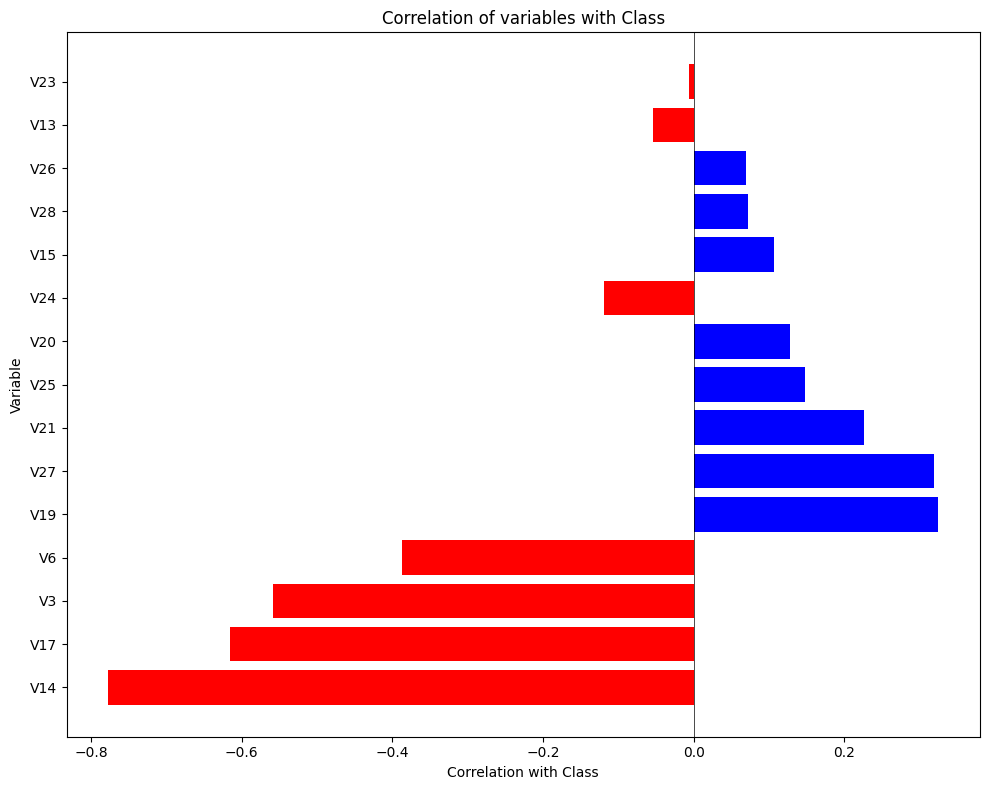

  Removing V17 (corr with Class: 0.6161) vs V14 (corr with Class: 0.7775)

Initial PCA variables: 15
Removed variables: 1
Final variables: 14
Train set - Día: 2023-01-01
  Shape: (359451, 14)
  Clase 0: 144377
  Clase 1: 215074
  % Fraude: 59.83%

Test set - Día: 2023-01-02
  Shape: (140549, 14)
  Clase 0: 139691
  Clase 1: 858
  % Fraude: 0.61%
Class
1    215074
0    144377
Name: count, dtype: int64

=== Training with LightGBM===

===== LightGBM (PCA variables, temporal split) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    139691
           1       0.73      0.73      0.73       858

    accuracy                           1.00    140549
   macro avg       0.87      0.87      0.87    140549
weighted avg       1.00      1.00      1.00    140549

ROC AUC: 0.9226

Matriz de confusión:
[[139463    228]
 [   229    629]]

=== Feature Importance (Top 10) ===
V14    990
V20    742
V26    722
V3     711
V13    704
V19    684
V15    6

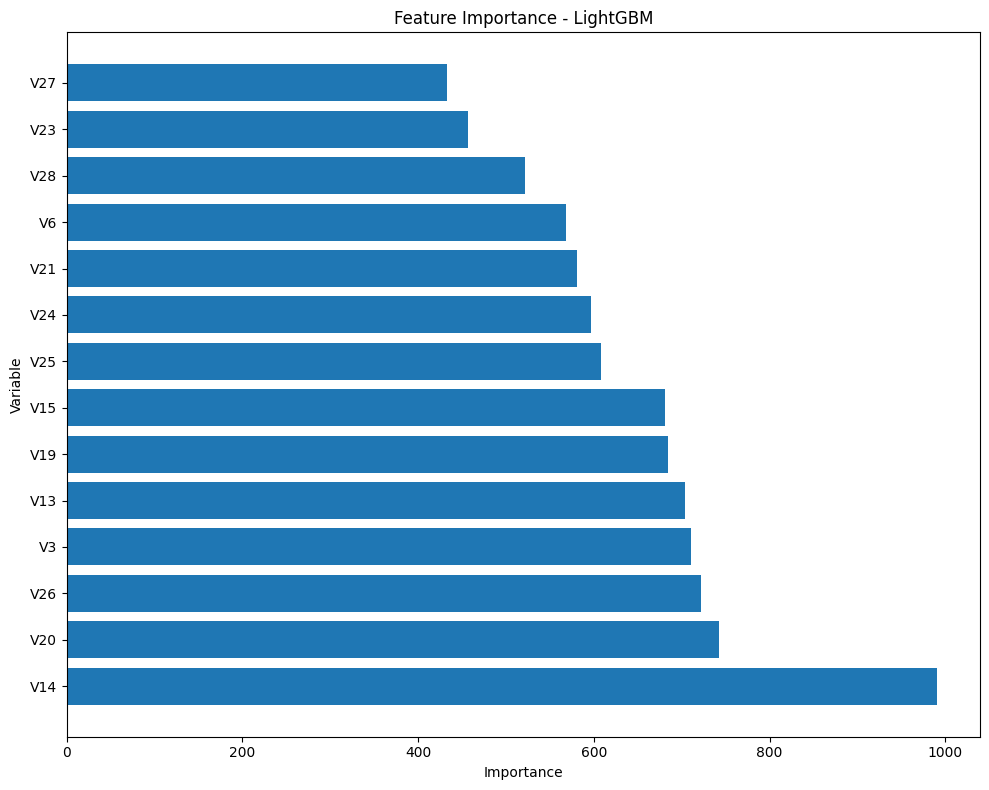

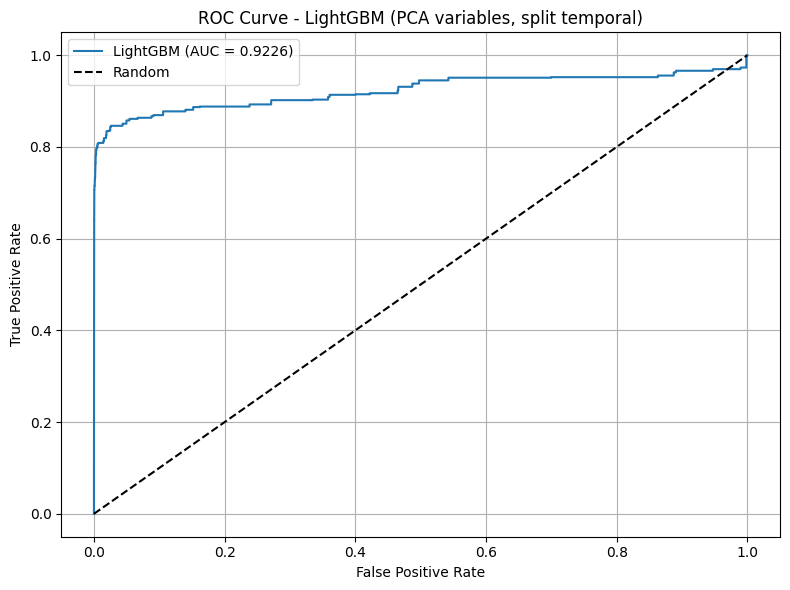

In [ ]:
# ==============================================================================
# Feature Selection and Temporal Split
# ==============================================================================

#CSV_EXPORTS = Path().resolve() / "csv_exports"
#df_full = pd.read_csv(CSV_EXPORTS / "df_exp_50.csv")
df_full = pd.read_csv("df_exp_50.csv")

# Verifying it contains timestamp
if 'timestamp' in df_full.columns:
    print("Column timestamp found")
    df_work = df_full.copy()
else:
    raise ValueError("The df does not have a timestamp column.")

# =============================
# Treating temporal data
# =============================

ts_series = df_work['timestamp'] if 'timestamp' in df_work.columns else None

if ts_series is not None and bool(ts_series.notna().any()):
    ts_series = pd.to_datetime(ts_series, errors='coerce')
    df_work['timestamp'] = ts_series

    # Extract day
    date_series = ts_series.dt.date
    df_work['date'] = date_series

    # Unique days
    unique_dates = pd.Series(date_series).value_counts().sort_index()
    print(f"Number of unique days: {pd.Series(date_series).nunique()}")
    print("\nDistribution of transactions per day:")
    print(unique_dates.head(10))

    # Verifying class imbalance by day
    print("\n=== Balance of Class by day ===")
    for date in sorted(pd.Series(date_series).dropna().unique())[:5]:
        day_mask = df_work['date'] == date
        day_data = df_work.loc[day_mask]
        class_counts = day_data['Class'].value_counts()
        total_day = len(day_data)
        fraud_count = float(class_counts.get(1, 0))
        print(f"\nDate: {date}")
        print(f"  Total transactions: {total_day}")
        print(f"  Class 0 (No fraud): {class_counts.get(0, 0)}")
        print(f"  Class 1 (Fraud): {int(fraud_count)}")
        if total_day > 0:
            print(f"  % Fraud: {fraud_count / float(total_day) * 100:.2f}%")

    # Train and test split
    sorted_dates = sorted(pd.Series(date_series).dropna().unique())
    if len(sorted_dates) >= 2:
        train_date = sorted_dates[0]  # First day for train
        test_date = sorted_dates[1]   # Second day for test
        print(f"Train date: {train_date}")
        print(f"Test date: {test_date}")
    else:
        print("\nOnly one day in data. Could not make split")
        train_date = sorted_dates[0] if len(sorted_dates) > 0 else None
        test_date = None

# =============================
# 2. Selecting PCA variables
# =============================

pca_vars = [f'V{i}' for i in range(1, 29)]
available_pca_vars = [var for var in pca_vars if var in df_work.columns]
subset_vars = list(available_pca_vars)

print(f"Available PCA variables: {len(available_pca_vars)} of 28")
print(f"Variables: {available_pca_vars}")

if len(available_pca_vars) == 0:
    raise ValueError("No available PCA variables")

# Create df with PCA variables, target and date
cols_to_include = subset_vars + ['Class']
if 'date' in df_work.columns:
    cols_to_include.append('date')

df_pca = df_work[cols_to_include].copy()

pca_only: pd.DataFrame = df_pca.loc[:, subset_vars]
missing_pca = pca_only.isnull().sum()
if missing_pca.sum() > 0:
    print(f"\n Missing values in PCA variables:")
    print(missing_pca[missing_pca > 0])
    # Remove rows with missing values
    df_pca = df_pca.dropna(subset=subset_vars)
    pca_only = df_pca.loc[:, subset_vars]

print(f"\nShape of df: {df_pca.shape}")

# =============================
# 3. Analising correlations
# =============================

print("\n=== Analysis of correlations ===")

corr_matrix: pd.DataFrame = pca_only.corr().abs()

threshold = 0.8
high_corr_pairs: List[Tuple[str, str, float]] = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] >= threshold:
            high_corr_pairs.append((
                str(corr_matrix.columns[i]),
                str(corr_matrix.columns[j]),
                float(corr_matrix.iloc[i, j])
            ))

print(f"\nPaires with correlation >= {threshold}: {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nHighly correlated paires:")
    for var1, var2, corr_val in high_corr_pairs[:10]:
        print(f"  {var1} <-> {var2}: {corr_val:.4f}")

# =============================
# 4. Correlations with Class
# =============================

print("\n=== Correlations with Class ===")
corr_with_target: pd.DataFrame = df_pca.loc[:, subset_vars + ['Class']].corr()
target_corr = corr_with_target['Class'].drop('Class')
target_corr_abs = target_corr.abs().sort_values(ascending=False)

print(target_corr_abs.to_frame('Correlation_with_Class'))

plt.figure(figsize=(10, 8))
target_corr_sorted = target_corr.reindex(target_corr_abs.index)
target_corr_sorted_values: np.ndarray = target_corr_sorted.to_numpy(dtype=float)

colors = ['red' if x < 0 else 'blue' for x in target_corr_sorted_values]

yticks_positions = np.arange(len(target_corr_sorted_values))
yticks_labels: List[str] = [str(idx) for idx in target_corr_sorted.index]

plt.barh(yticks_positions, target_corr_sorted_values, color=colors)
plt.yticks(yticks_positions, yticks_labels)
plt.xlabel('Correlation with Class')
plt.ylabel('Variable')
plt.title('Correlation of variables with Class')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# =============================
# 5. Removing correlated variables
# =============================

vars_to_remove: set[str] = set()
vars_considered: set[str] = set(available_pca_vars)

for var1, var2, corr_val in high_corr_pairs:
    if var1 in vars_to_remove or var2 in vars_to_remove:
        continue

    corr1_with_target = abs(float(target_corr[var1]))
    corr2_with_target = abs(float(target_corr[var2]))

    if corr1_with_target >= corr2_with_target:
        vars_to_remove.add(var2)
        print(
            f"  Removing {var2} (corr with Class: {corr2_with_target:.4f}) "
            f"vs {var1} (corr with Class: {corr1_with_target:.4f})"
        )
    else:
        vars_to_remove.add(var1)
        print(
            f"  Removing {var1} (corr with Class: {corr1_with_target:.4f}) "
            f"vs {var2} (corr with Class: {corr2_with_target:.4f})"
        )

final_pca_vars = [var for var in available_pca_vars if var not in vars_to_remove]

print(f"\nInitial PCA variables: {len(available_pca_vars)}")
print(f"Removed variables: {len(vars_to_remove)}")
print(f"Final variables: {len(final_pca_vars)}")

cols_final = final_pca_vars + ['Class']
if 'date' in df_pca.columns:
    cols_final.append('date')
df_pca_final = df_pca[cols_final].copy()

# =============================
# 6. Temporal split
# =============================

if train_date is not None and test_date is not None and 'date' in df_pca_final.columns:
    train_mask = df_pca_final['date'] == train_date
    test_mask = df_pca_final['date'] == test_date

    X_train_temp = df_pca_final.loc[train_mask, final_pca_vars].copy()
    y_train_temp = df_pca_final.loc[train_mask, 'Class'].copy()

    X_test_temp = df_pca_final.loc[test_mask, final_pca_vars].copy()
    y_test_temp = df_pca_final.loc[test_mask, 'Class'].copy()

    print(f"Train set - Día: {train_date}")
    print(f"  Shape: {X_train_temp.shape}")
    print(f"  Clase 0: {(y_train_temp == 0).sum()}")
    print(f"  Clase 1: {(y_train_temp == 1).sum()}")
    if len(y_train_temp) > 0:
        print(f"  % Fraude: {(y_train_temp == 1).sum() / len(y_train_temp) * 100:.2f}%")

    print(f"\nTest set - Día: {test_date}")
    print(f"  Shape: {X_test_temp.shape}")
    print(f"  Clase 0: {(y_test_temp == 0).sum()}")
    print(f"  Clase 1: {(y_test_temp == 1).sum()}")
    if len(y_test_temp) > 0:
        print(f"  % Fraude: {(y_test_temp == 1).sum() / len(y_test_temp) * 100:.2f}%")
    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp

else:
    print("Couldn't make temporal split")
    X_all = df_pca_final.loc[:, final_pca_vars].copy()
    y_all = df_pca_final.loc[:, 'Class'].copy()

    split_result = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        random_state=42,
        stratify=y_all,
    )
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = cast(
        Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series],
        split_result,
    )

    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp

# =============================
# 7. LightGBM training
# =============================

print("\n=== Training with LightGBM===")

lgb_model_pca = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

lgb_model_pca.fit(X_train_res_temp, y_train_res_temp)
y_pred_lgb_pca = lgb_model_pca.predict(X_test_temp)
y_proba_lgb_pca = lgb_model_pca.predict_proba(X_test_temp)[:, 1]

print("\n===== LightGBM (PCA variables, temporal split) =====")
print(classification_report(y_test_temp, y_pred_lgb_pca))
print(f"ROC AUC: {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f}")

cm = confusion_matrix(y_test_temp, y_pred_lgb_pca)
print("\nMatriz de confusión:")
print(cm)
feature_importance_pca = pd.Series(
    lgb_model_pca.feature_importances_,
    index=final_pca_vars
).sort_values(ascending=False)

print("\n=== Feature Importance (Top 10) ===")
print(feature_importance_pca.head(10))

plt.figure(figsize=(10, 8))
fi_values: np.ndarray = feature_importance_pca.to_numpy(dtype=float)
fi_positions = np.arange(len(fi_values))
fi_labels: List[str] = [str(idx) for idx in feature_importance_pca.index]

plt.barh(fi_positions, fi_values)
plt.yticks(fi_positions, fi_labels)
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_temp, y_proba_lgb_pca)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM (PCA variables, split temporal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### LightGBM

In [ ]:
# ============================================================================
# Detailed analysis with appropriate metrics for extreme imbalance
# ============================================================================

def eval_desbalanceado_detallado1(df_in: pd.DataFrame, name: str) -> dict:
    """
    - Temporal split: Day 1 / Day 2
    - Uses only PCA variables (V1-V28)
    - Removes highly correlated PCA variables, keeping the one most correlated
    with the target.
    Returns a dictionary with key comparison metrics
    """
    print(f"\n{'='*60}")
    print(f"Detailed Analysis: {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Initial selection of PCA variables (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No V1-V28 variables found; skipping.")
        return {}

    print(f"Available PCA variables: {len(available_pca_vars)} -> {available_pca_vars}")

    # Remove rows with NaN in PCA vars or Class
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Temporal Split (Day 1 for train, Day 2 for test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Only one day found; evaluation skipped.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Analysis of correlations between PCA vars and with Target
    # ---------------------------------------------------------------------
    print("\n=== PCA Variable Correlation Analysis ===")
    pca_only_train: pd.DataFrame = train_df.loc[:, available_pca_vars]

    # Absolute correlation matrix between PCA vars
    corr_matrix: pd.DataFrame = pca_only_train.corr().abs()

    # Pairs of highly correlated variables
    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Variable pairs with correlation >= {threshold_corr}: {len(high_corr_pairs)}")

    # Correlations with Target (Class) in TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    print("\nCorrelations with Class (sorted by |correlation|):")
    print(target_corr.abs().sort_values(ascending=False).to_frame("Correlation_with_Class"))

    # ---------------------------------------------------------------------
    # 4) Remove highly correlated PCA variables
    # ---------------------------------------------------------------------
    print("\n=== Removing Highly Correlated PCA Variables ===")
    vars_to_remove: set[str] = set()

    for var1, var2, corr_val in high_corr_pairs:
        # If one was already removed in a previous step, skip pair
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        corr1_with_target = abs(float(target_corr[var1]))
        corr2_with_target = abs(float(target_corr[var2]))

        if corr1_with_target >= corr2_with_target:
            # Keep var1, remove var2
            vars_to_remove.add(var2)
            print(
                f"  Removing {var2} (|corr target|={corr2_with_target:.4f}) "
                f"vs {var1} (|corr target|={corr1_with_target:.4f})  [corr {corr_val:.4f}]"
            )
        else:
            vars_to_remove.add(var1)
            print(
                f"  Removing {var1} (|corr target|={corr1_with_target:.4f}) "
                f"vs {var2} (|corr target|={corr2_with_target:.4f})  [corr {corr_val:.4f}]"
            )

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]

    print(f"\nInitial PCA variables: {len(available_pca_vars)}")
    print(f"Variables removed due to high correlation: {len(vars_to_remove)} -> {sorted(list(vars_to_remove))}")
    print(f"Final PCA variables used: {len(final_pca_vars)} -> {final_pca_vars}")

    if not final_pca_vars:
        print("No PCA variables left after filtering; skipping.")
        return {}

    # ---------------------------------------------------------------------
    # 5) Drop duplicates using ONLY final PCA vars
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    print(f"\nShape train: {X_train.shape} | Shape test: {X_test.shape}")

    # ---------------------------------------------------------------------
    # 6) Train LightGBM model
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)

    # Prediction probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Confusion Matrix with threshold 0.5
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    print("\n--- Confusion Matrix (threshold=0.5) ---")
    print("                Predicted")
    print("              No Fraud   Fraud")
    print(f"Actual No Fraud   {cm_05[0,0]:6d}  {cm_05[0,1]:6d}")
    print(f"       Fraud       {cm_05[1,0]:6d}  {cm_05[1,1]:6d}")

    # Metrics per class with threshold 0.5
    tn, fp, fn, tp = cm_05.ravel()
    recall_fraude_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_fraude_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_no_fraude_05 = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # F1 Score
    f1_fraude_05 = (
        2 * (precision_fraude_05 * recall_fraude_05) / (precision_fraude_05 + recall_fraude_05)
        if (precision_fraude_05 + recall_fraude_05) > 0
        else 0.0
    )

    # F2 Score (Recall weighted x2 vs Precision)
    f2_fraude_05 = (
        5 * (precision_fraude_05 * recall_fraude_05) / ((4 * precision_fraude_05) + recall_fraude_05)
        if ((4 * precision_fraude_05) + recall_fraude_05) > 0
        else 0.0
    )

    print(f"\n--- Metrics with threshold=0.5 ---")
    print(f"Fraud Recall:      {recall_fraude_05:.4f} ({tp}/{tp+fn} frauds detected)")
    print(f"Fraud Precision:   {precision_fraude_05:.4f} ({tp}/{tp+fp} alerts are fraud)")
    print(f"No Fraud Recall:   {recall_no_fraude_05:.4f}")
    print(f"Fraud F1:          {f1_fraude_05:.4f}")
    print(f"Fraud F2:          {f2_fraude_05:.4f} (Prioritizes Recall)")

    # ---------------------------------------------------------------------
    # 8) Precision-Recall Curve and AUC-PR
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n--- Precision-Recall Curve ---")
    print(f"AUC-PR: {auc_pr:.4f} (more informative than ROC-AUC for extreme imbalance)")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ---------------------------------------------------------------------
    # 9) Optimal Threshold (Maximize F2 for Fraud)
    # ---------------------------------------------------------------------
    scores_list = []

    for thresh in thresholds_pr:
        y_pred_th = (y_proba >= thresh).astype(int)
        cm_th = confusion_matrix(y_test, y_pred_th)
        if cm_th.shape == (2, 2):
            tn_th, fp_th, fn_th, tp_th = cm_th.ravel()
            prec_th = tp_th / (tp_th + fp_th) if (tp_th + fp_th) > 0 else 0.0
            rec_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0.0

            f1_th = (
                2 * (prec_th * rec_th) / (prec_th + rec_th)
                if (prec_th + rec_th) > 0 else 0.0
            )

            f2_th = (
                5 * (prec_th * rec_th) / ((4 * prec_th) + rec_th)
                if ((4 * prec_th) + rec_th) > 0 else 0.0
            )

            scores_list.append((thresh, tp_th, fp_th, fn_th, prec_th, rec_th, f1_th, f2_th))

    # Initialization for optimal F2
    best_thresh_f2, best_tp_f2, best_fp_f2, best_fn_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = (
        0.5, 0, 0, 0, 0.0, 0.0, 0.0, 0.0
    )

    if scores_list:
        best_row_f2 = max(scores_list, key=lambda x: x[7])
        best_thresh_f2, best_tp_f2, best_fp_f2, best_fn_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row_f2

        # --- F2 Optimal Report ---
        print(f"\n--- Optimal Threshold (maximizes F2 - Recommended for Fraud) ---")
        print(f"Fraud F1: {best_f1_score:.4f}")
        print(f"Fraud F2: {best_f2_score:.4f}")
        print(f"Precision: {best_prec_f2:.4f}")
        print(f"Recall: {best_rec_f2:.4f}")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"Detected Frauds: {best_tp_f2}/{best_tp_f2 + best_fn_f2} (Recall: {best_rec_f2:.4f})")
        print(f"False Positives: {best_fp_f2}")

    # ---------------------------------------------------------------------
    # 10) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Precision-Recall (AUC={auc_pr:.4f})', linewidth=2)
    plt.xlabel('Recall (Fraud)', fontsize=12)
    plt.ylabel('Precision (Fraud)', fontsize=12)
    plt.title(f'Precision-Recall Curve - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraud', density=True)
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraud', density=True)
    plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
    if scores_list:
        plt.axvline(
            x=best_thresh_f2,
            color='blue',
            linestyle=':',
            linewidth=2,
            label=f'Thresh F2 ({best_thresh_f2:.3f})'
        )
    plt.xlabel('Predicted Probability (Fraud)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title(f'Probability Distribution - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTest distribution: {y_test.value_counts().to_dict()}")
    print(f"Frauds in test: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

    # ---------------------------------------------------------------------
    # 11) Return metrics for comparison
    # ---------------------------------------------------------------------
    return {
        'dataset': name,
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,

        # Metrics at 0.5
        'f1_fraude_05': f1_fraude_05,
        'f2_fraude_05': f2_fraude_05,
        'precision_fraude_05': precision_fraude_05,
        'recall_fraude_05': recall_fraude_05,

        # Optimal Metrics (F2)
        'best_thresh_f2': best_thresh_f2,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,

        'fraudes_totales': int(y_test.sum()),
    }


Detailed Analysis: df_exp_50
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 0

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.727359
V17                0.553309
V3                 0.535642
V6                 0.387688
V19                0.302783
V27                0.285762
V21                0.198478
V24                0.133057
V20                0.099589
V28                0.063750
V25                0.046718
V26                0.046572
V13                0.044706
V15                0.022512
V23                0.008710

=== Removing Highly Correlated PCA Variables ===

Initial PCA variables: 15
Variables removed due to high correlation: 0 -> []
Final PCA variables used: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V

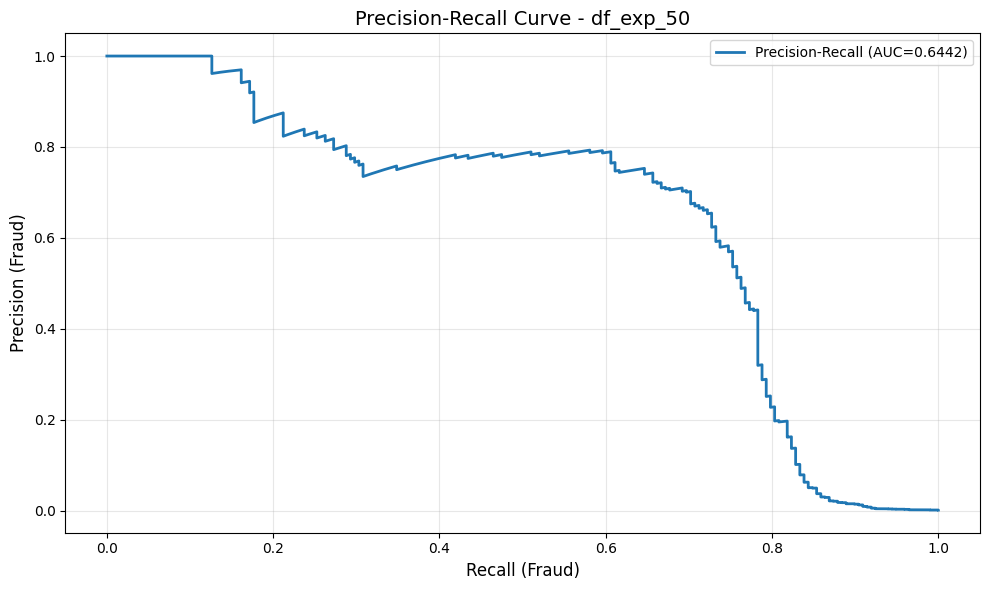

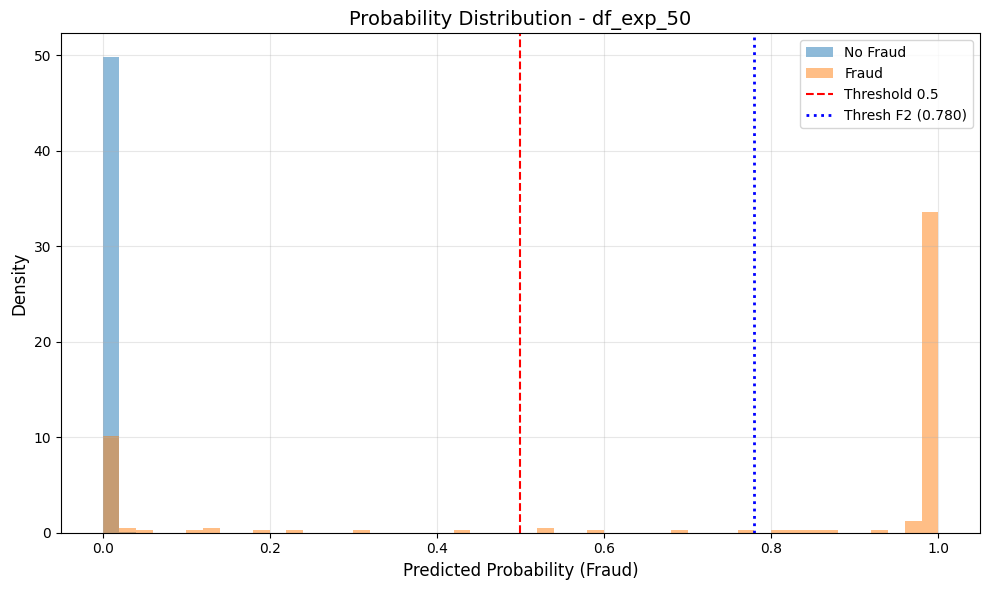


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

Detailed Analysis: df_exp_random
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 0

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.576218
V17                0.559102
V3                 0.441820
V21                0.148974
V27                0.122119
V6                 0.099171
V19                0.089444
V20                0.026423
V24                0.023732
V28                0.015154
V25                0.012928
V26                0.010298
V13                0.007960
V15                0.004202
V23                0.000627

=== Removing Highly Correlated PCA Variables ===

Initial PCA variables: 15
Variables removed due to high correlation: 0 -> []
Fin

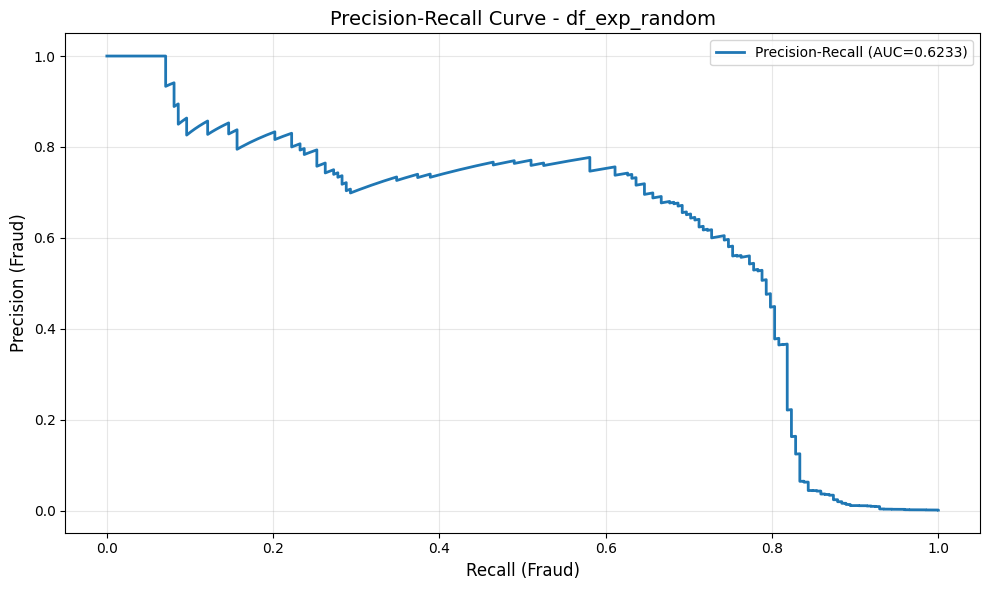

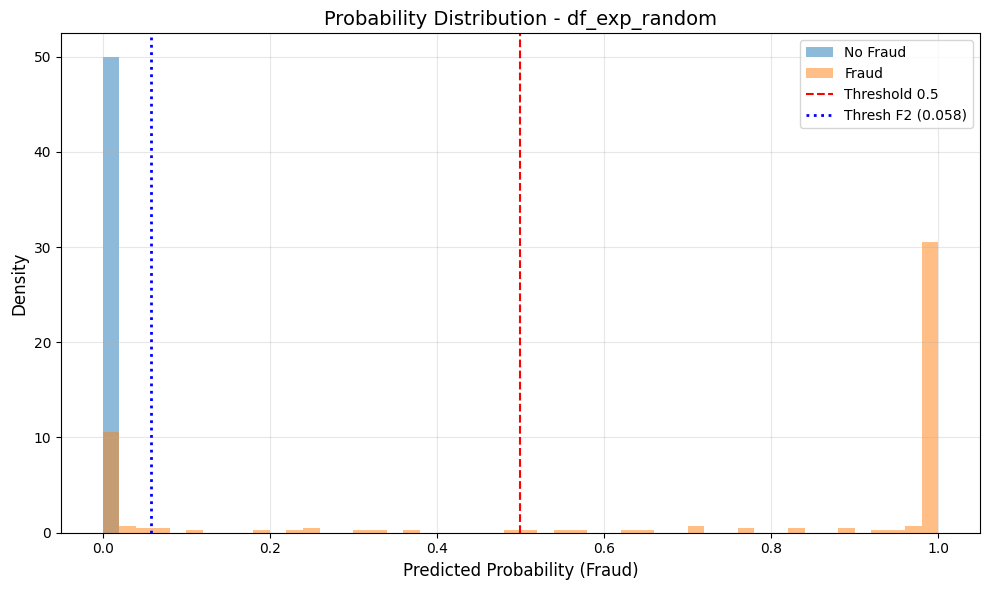


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

Detailed Analysis: df_exp_63
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 1

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.772656
V17                0.609518
V3                 0.589878
V6                 0.409026
V19                0.330217
V27                0.318911
V21                0.227273
V24                0.133382
V20                0.107478
V28                0.071008
V25                0.051521
V26                0.046173
V13                0.045864
V15                0.023049
V23                0.009714

=== Removing Highly Correlated PCA Variables ===
  Removing V17 (|corr target|=0.6095) vs V14 (|corr target|=0.7727)  [corr 0.8147]

I

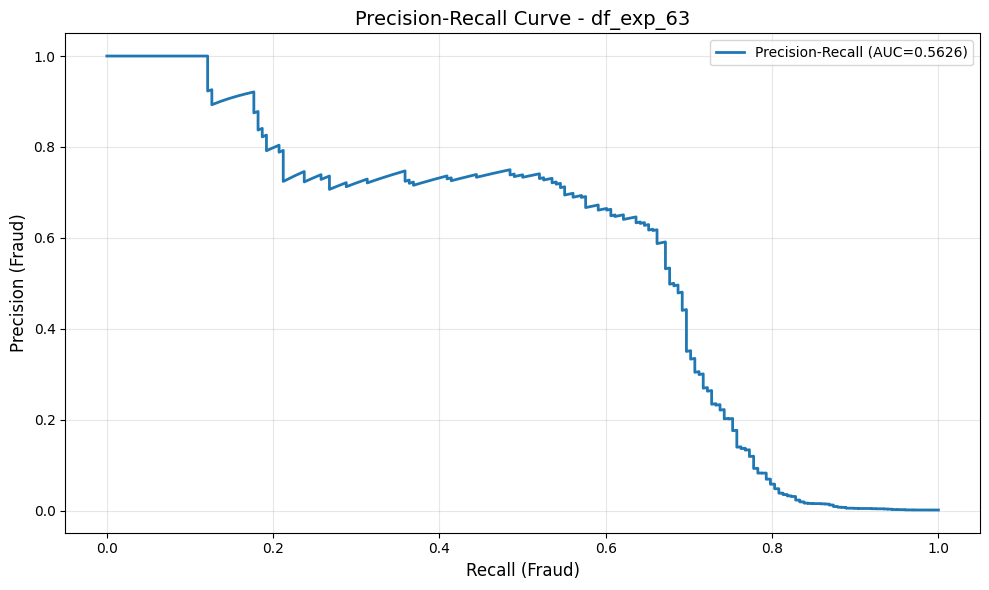

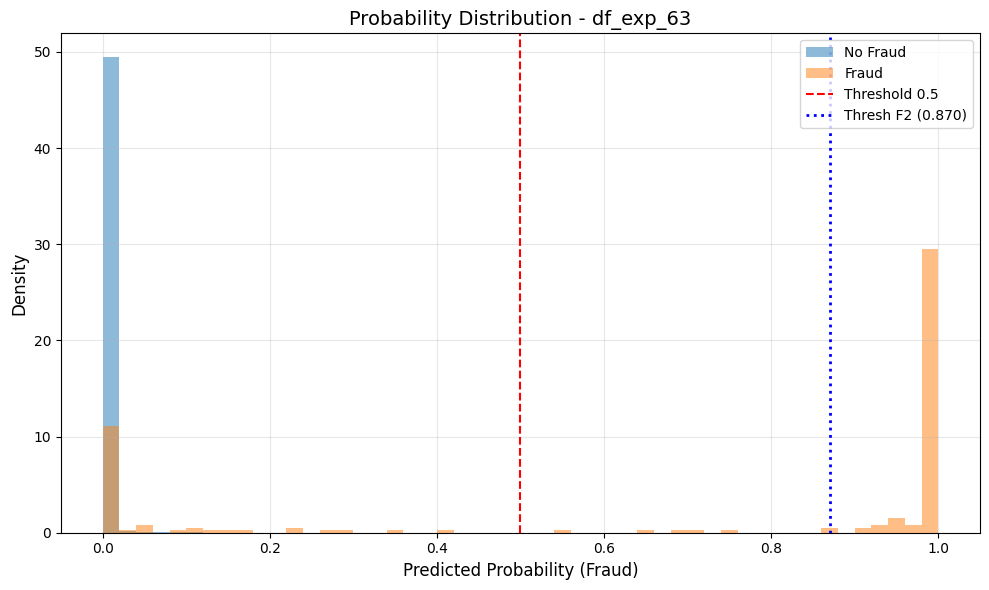


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

Detailed Analysis: df_exp_same_prop
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 0

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.575765
V17                0.556838
V3                 0.438239
V21                0.154962
V27                0.119500
V6                 0.096908
V19                0.088323
V20                0.023973
V24                0.022824
V28                0.017197
V25                0.010843
V13                0.009529
V26                0.008057
V15                0.002410
V23                0.001577

=== Removing Highly Correlated PCA Variables ===

Initial PCA variables: 15
Variables removed due to high correlation: 0 -> []


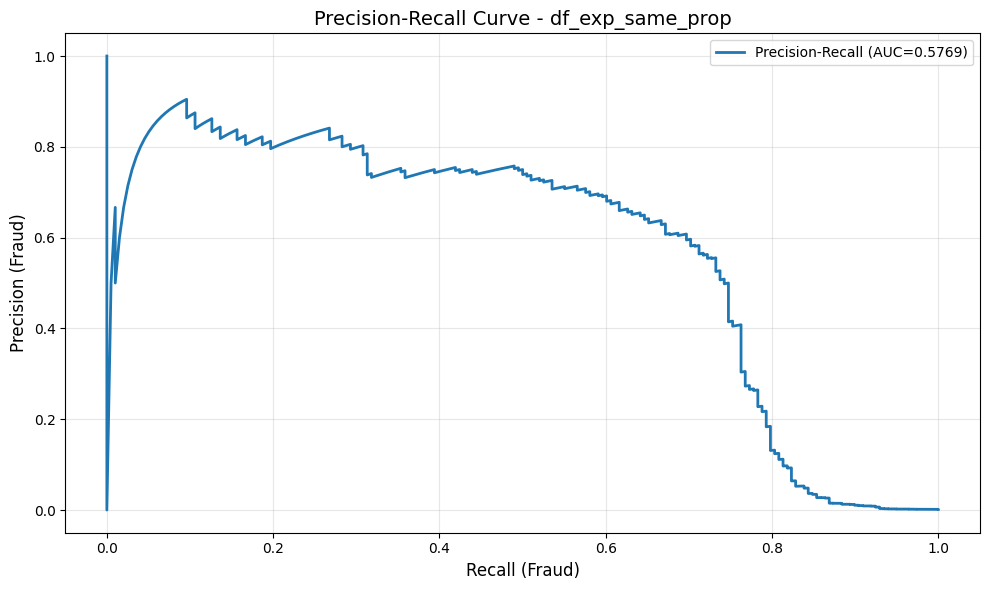

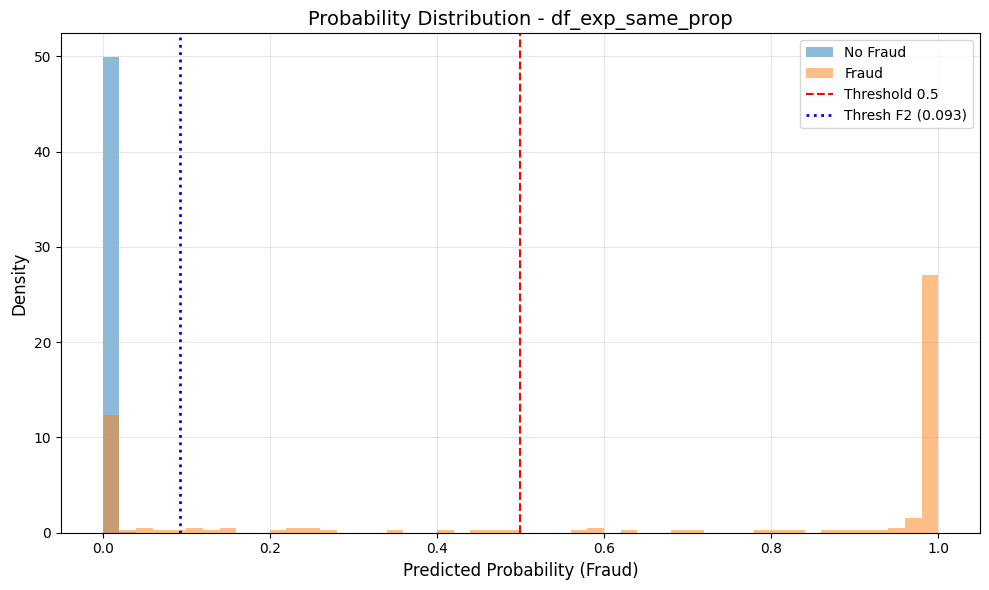


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

FINAL COMPARATIVE TABLE (Sorted by F2-Score)
         dataset  f1_fraude_opt  f2_fraude_opt  precision_at_f2_opt  recall_at_f2_opt   auc_pr  roc_auc  best_thresh_f2
   df_exp_random       0.649682       0.718310             0.560440          0.772727 0.623281 0.947597        0.057931
       df_exp_50       0.688995       0.711462             0.654545          0.727273 0.644237 0.948585        0.779598
df_exp_same_prop       0.631808       0.688509             0.555556          0.732323 0.576860 0.938718        0.093060
       df_exp_63       0.628842       0.653884             0.591111          0.671717 0.562630 0.928938        0.870444


In [ ]:
# ============================================================================
# Mass evaluation execution on experimental datasets
# ============================================================================

# 1. Define the list of tuples (dataframe, name)
df_exp_50 = pd.read_csv("df_exp_50.csv")
df_exp_random = pd.read_csv("df_exp_random.csv")
df_exp_63 = pd.read_csv("df_exp_63.csv")
df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_random, 'df_exp_random'),
    (df_exp_63, 'df_exp_63'),
    (df_exp_same_prop, 'df_exp_same_prop')
]

# 2. List to accumulate results
results_list = []

# 3. Execution loop
for df_dataset, name_dataset in datasets_to_evaluate:
    try:
        # Run the function with F2 included
        metrics = eval_desbalanceado_detallado1(df_dataset, name_dataset)

        # If the function returns data (not empty due to error), save it
        if metrics:
            results_list.append(metrics)

    except Exception as e:
        print(f"Error processing {name_dataset}: {e}")

# ============================================================================
# Final Comparative Summary
# ============================================================================

if results_list:
    df_results = pd.DataFrame(results_list)

    # Key columns to show in the summary (prioritizing F2 and Recall)
    cols_to_show = [
        'dataset',
        'f1_fraude_opt',
        'f2_fraude_opt',
        'precision_at_f2_opt',
        'recall_at_f2_opt',
        'auc_pr',
        'roc_auc',
        'best_thresh_f2'
    ]

    # Filter only columns that exist (for safety)
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("FINAL COMPARATIVE TABLE (Sorted by F2-Score)")
    print("="*80)

    # Sort by F2 Score descending
    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    # Print
    print(summary_sorted.to_string(index=False))

else:
    print("No results generated to show.")

We observe that the balanced dfs contain correlation, which didn't make sense since the variables are supposed to come from a PCA, thus we study correlation for Class = 1 (in the preprocessing.ipynb file) and create new datasets taking into account this correlation.

Now, we do the same with all the datasets to compare them but with Random Forest instead of LightGBM to see if it performs better.

### CatBoost

In [24]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix

def eval_desbalanceado_catboost(df_in: pd.DataFrame, name: str) -> dict:
    print(f"\n{'='*60}")
    print(f"Detailed analysis (CatBoost): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Initial selection of PCA variables (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No V1-V28 variables found; skipping.")
        return {}

    print(f"Available PCA variables: {len(available_pca_vars)} -> {available_pca_vars}")

    # Remove rows with NaN
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Temporal Split (Day 1 train, Day 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Only one day found; evaluation skipped.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Correlation Analysis
    # ---------------------------------------------------------------------
    print("\n=== PCA Variable Correlation Analysis ===")
    pca_only_train = train_df.loc[:, available_pca_vars]
    corr_matrix = pca_only_train.corr().abs()

    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )

    # Correlations with the target in TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    # ---------------------------------------------------------------------
    # 4) Remove highly correlated PCA variables
    # ---------------------------------------------------------------------
    vars_to_remove = set()
    for var1, var2, corr_val in high_corr_pairs:
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue
        c1 = abs(float(target_corr[var1]))
        c2 = abs(float(target_corr[var2]))
        if c1 >= c2:
            vars_to_remove.add(var2)
        else:
            vars_to_remove.add(var1)

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]
    print(f"Variables removed: {len(vars_to_remove)} | Final: {len(final_pca_vars)}")

    # ---------------------------------------------------------------------
    # 5) Deduplicate and prepare X, y
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train, y_train = train_df[final_pca_vars], train_df['Class']
    X_test, y_test = test_df[final_pca_vars], test_df['Class']

    # ---------------------------------------------------------------------
    # 6) Train CatBoost
    # ---------------------------------------------------------------------
    # CatBoost uses auto_class_weights='Balanced' to handle imbalance
    model = CatBoostClassifier(
        iterations=200,
        depth=6,
        learning_rate=0.05,
        auto_class_weights='Balanced', # Imbalance handling
        random_seed=42,
        verbose=0,                     # Silent training
        allow_writing_files=False
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Metrics & Thresholds (0.5 and Optimal F2)
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\nAUC-PR: {auc_pr:.4f} | ROC-AUC: {roc_auc:.4f}")

    # 0.5 Metrics
    y_pred_05 = (y_proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_05).ravel()
    rec_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_05 = 2 * (prec_05 * rec_05) / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print("\n--- Confusion Matrix (CatBoost at 0.5) ---")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")
    print(f"F1 Score: {f1_05:.4f}")
    print(f"F2 Score: {f2_05:.4f}")

    # Search for Best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = 0.5, 0.0, 0.0, 0.0, 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

        # Recalculate TP/FP for exact reporting with that threshold
        y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

        print(f"\n--- Optimal Threshold CatBoost (Max F2) ---")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"F1 Score:  {best_f1_score:.4f}")
        print(f"F2 Score:  {best_f2_score:.4f}")
        print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
        print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")

    # ---------------------------------------------------------------------
    # 8) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(recall_arr, precision_arr, label=f'CatBoost PR Curve (AUC={auc_pr:.4f})', color='orange')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve - CatBoost - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return {
        'dataset': name,
        'model': 'CatBoost_PCA',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (CatBoost): df_exp_50
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variables removed: 0 | Final: 15

AUC-PR: 0.6563 | ROC-AUC: 0.9164

--- Confusion Matrix (CatBoost at 0.5) ---
TN: 134131 | FP: 1003
FN: 46 | TP: 152
F1 Score: 0.2247
F2 Score: 0.3903

--- Optimal Threshold CatBoost (Max F2) ---
Threshold: 0.9311
F1 Score:  0.6974
F2 Score:  0.6911
Precision: 0.7083 (FP: 56)
Recall:    0.6869 (TP: 136)


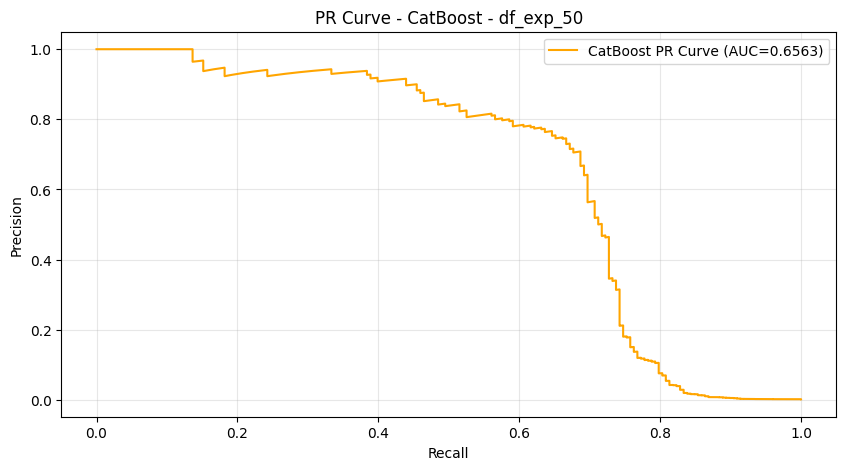


Detailed analysis (CatBoost): df_exp_63
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variables removed: 1 | Final: 14

AUC-PR: 0.5875 | ROC-AUC: 0.9314

--- Confusion Matrix (CatBoost at 0.5) ---
TN: 133352 | FP: 1782
FN: 49 | TP: 149
F1 Score: 0.1400
F2 Score: 0.2736

--- Optimal Threshold CatBoost (Max F2) ---
Threshold: 0.9775
F1 Score:  0.6829
F2 Score:  0.6542
Precision: 0.7368 (FP: 45)
Recall:    0.6364 (TP: 126)


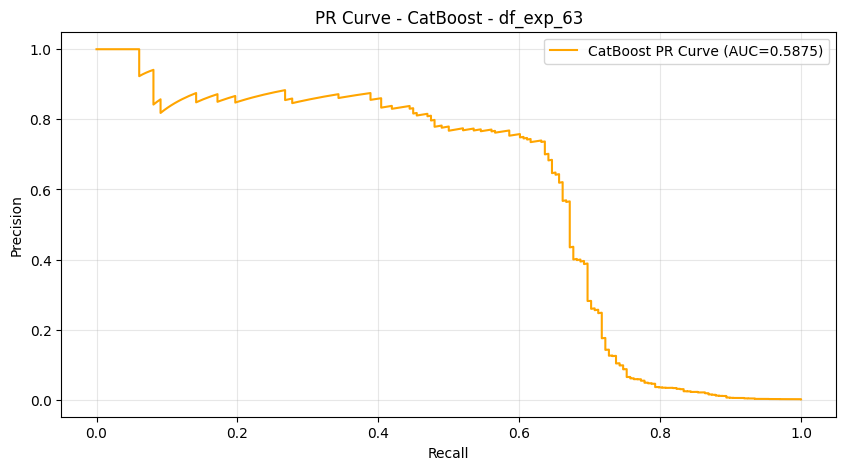


FINAL COMPARATIVE TABLE (Sorted by F2-Score)
  dataset  f1_fraude_opt  f2_fraude_opt  recall_at_f2_opt  precision_at_f2_opt   auc_pr  roc_auc  best_thresh_f2
df_exp_50       0.697436       0.691057          0.686869             0.708333 0.656301 0.916375        0.931064
df_exp_63       0.682927       0.654206          0.636364             0.736842 0.587464 0.931352        0.977512


In [25]:
# 1. Define the list of tuples (dataframe, name)

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_63, 'df_exp_63')
]

# 2. List to accumulate results
results_list = []

for df_dataset, name_dataset in datasets_to_evaluate:
  metrics = eval_desbalanceado_catboost(df_dataset, name_dataset)

  if metrics:
      results_list.append(metrics)


# Final Comparative Summary
if results_list:
    df_results = pd.DataFrame(results_list)

    # Key columns to show in the summary (prioritizing F2 and Recall)
    cols_to_show = [
        'dataset',
        'f1_fraude_opt',
        'f2_fraude_opt',
        'recall_at_f2_opt',
        'precision_at_f2_opt',
        'auc_pr',
        'roc_auc',
        'best_thresh_f2'
    ]
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("FINAL COMPARATIVE TABLE (Sorted by F2-Score)")
    print("="*80)

    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    print(summary_sorted.to_string(index=False))

else:
    print("No results generated to show.")

### XGBoost

In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score, confusion_matrix

def eval_desbalanceado_xgboost(df_in: pd.DataFrame, name: str) -> dict:
    print(f"\n{'='*60}")
    print(f"Detailed analysis (XGBoost): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Initial selection of PCA variables (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No V1-V28 variables found; skipping.")
        return {}

    print(f"Available PCA variables: {len(available_pca_vars)} -> {available_pca_vars}")

    # Remove rows with NaN
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Temporal Split (Day 1 train, Day 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Only one day found; evaluation skipped.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Correlation Analysis
    # ---------------------------------------------------------------------
    print("\n=== PCA Variable Correlation Analysis ===")
    pca_only_train = train_df.loc[:, available_pca_vars]
    corr_matrix = pca_only_train.corr().abs()

    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )

    # Correlations with the target in TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    # ---------------------------------------------------------------------
    # 4) Remove highly correlated PCA variables
    # ---------------------------------------------------------------------
    vars_to_remove = set()
    for var1, var2, corr_val in high_corr_pairs:
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue
        c1 = abs(float(target_corr[var1]))
        c2 = abs(float(target_corr[var2]))
        if c1 >= c2:
            vars_to_remove.add(var2)
        else:
            vars_to_remove.add(var1)

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]
    print(f"Variables removed: {len(vars_to_remove)} | Final: {len(final_pca_vars)}")

    # ---------------------------------------------------------------------
    # 5) Deduplicate and prepare X, y
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train, y_train = train_df[final_pca_vars], train_df['Class']
    X_test, y_test = test_df[final_pca_vars], test_df['Class']

    # ---------------------------------------------------------------------
    # 6) Train XGBoost
    # ---------------------------------------------------------------------
    # Calculate scale_pos_weight (Sum of negative / Sum of positive)
    ratio = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,              # Reduced from 15 (RF) as GBTs need shallower trees
        learning_rate=0.05,
        scale_pos_weight=ratio,    # Imbalance handling
        tree_method='hist',        # Optimized for speed
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Metrics & Thresholds (0.5 and Optimal F2)
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\nAUC-PR: {auc_pr:.4f} | ROC-AUC: {roc_auc:.4f}")

    # 0.5 Metrics
    y_pred_05 = (y_proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_05).ravel()
    rec_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_05 = 2 * (prec_05 * rec_05) / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print("\n--- Confusion Matrix (RF at 0.5) ---")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")
    print(f"F1 Score: {f1_05:.4f}")
    print(f"F2 Score: {f2_05:.4f}")

    # Search for Best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = 0.5, 0.0, 0.0, 0.0, 0.0

    if scores_list:
        # Tuple: (thresh, prec, rec, f2) -> Index 3 is F2
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

        # Recalculate TP/FP for exact reporting with that threshold
        y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

        print(f"\n--- Optimal Threshold RF (Max F2) ---")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"F1 Score:  {best_f1_score:.4f}")
        print(f"F2 Score:  {best_f2_score:.4f}")
        print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
        print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")

    # ---------------------------------------------------------------------
    # 8) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(recall_arr, precision_arr, label=f'XGBoost PR Curve (AUC={auc_pr:.4f})', color='blue')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve - XGBoost - {name}')
    plt.legend()
    plt.show()

    return {
        'dataset': name,
        'model': 'XGBoost_PCA',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (XGBoost): df_exp_50
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variables removed: 0 | Final: 15


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:18:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AUC-PR: 0.6253 | ROC-AUC: 0.9438

--- Confusion Matrix (RF at 0.5) ---
TN: 134685 | FP: 449
FN: 45 | TP: 153
F1 Score: 0.3825
F2 Score: 0.5488

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.9497
F1 Score:  0.6884
F2 Score:  0.6905
Precision: 0.6850 (FP: 63)
Recall:    0.6919 (TP: 137)


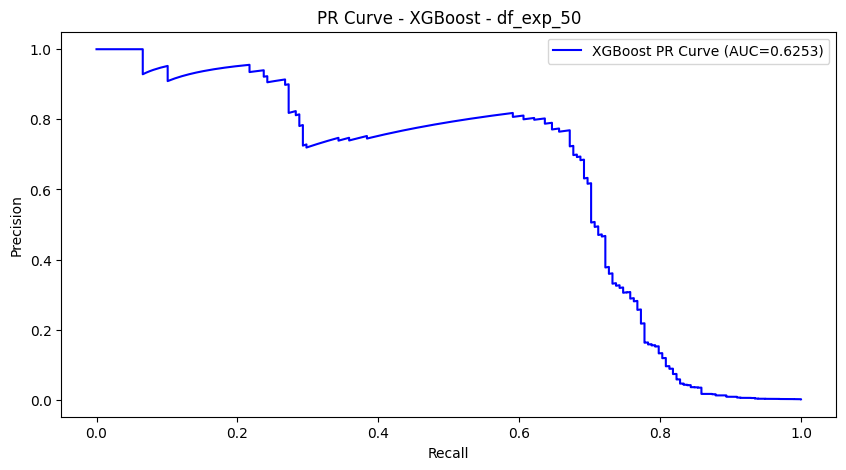


Detailed analysis (XGBoost): df_exp_random
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variables removed: 0 | Final: 15


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:18:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AUC-PR: 0.6012 | ROC-AUC: 0.9295

--- Confusion Matrix (RF at 0.5) ---
TN: 134856 | FP: 278
FN: 60 | TP: 138
F1 Score: 0.4495
F2 Score: 0.5712

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.9644
F1 Score:  0.6736
F2 Score:  0.6602
Precision: 0.6973 (FP: 56)
Recall:    0.6515 (TP: 129)


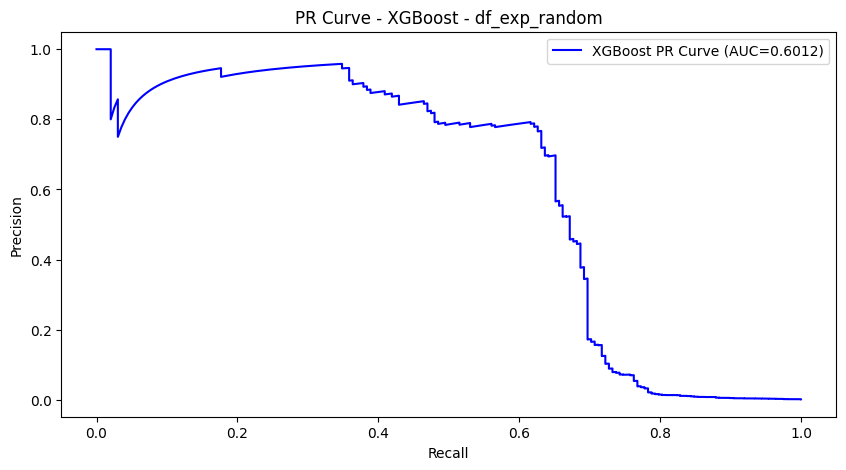


Detailed analysis (XGBoost): df_exp_63
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variables removed: 1 | Final: 14


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:18:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AUC-PR: 0.5373 | ROC-AUC: 0.9331

--- Confusion Matrix (RF at 0.5) ---
TN: 134723 | FP: 411
FN: 55 | TP: 143
F1 Score: 0.3803
F2 Score: 0.5312

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.9704
F1 Score:  0.6465
F2 Score:  0.6465
Precision: 0.6465 (FP: 70)
Recall:    0.6465 (TP: 128)


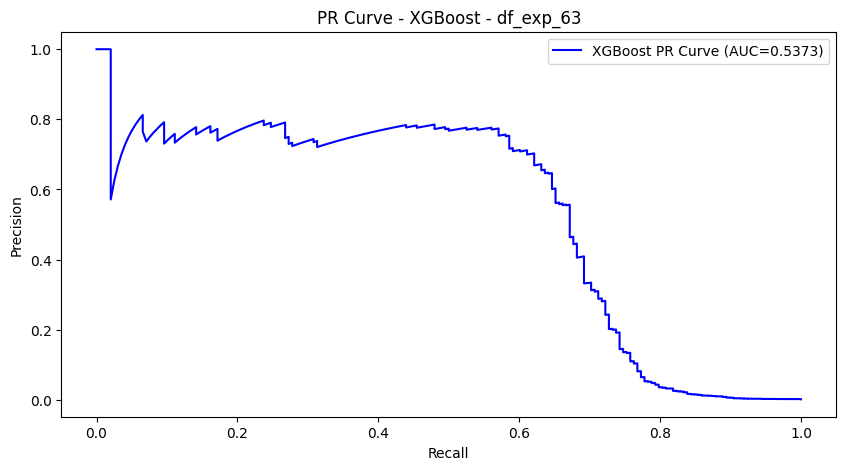


Detailed analysis (XGBoost): df_exp_same_prop
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variables removed: 0 | Final: 15


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:19:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



AUC-PR: 0.5994 | ROC-AUC: 0.9390

--- Confusion Matrix (RF at 0.5) ---
TN: 134626 | FP: 508
FN: 58 | TP: 140
F1 Score: 0.3310
F2 Score: 0.4861

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.9695
F1 Score:  0.6923
F2 Score:  0.6576
Precision: 0.7590 (FP: 40)
Recall:    0.6364 (TP: 126)


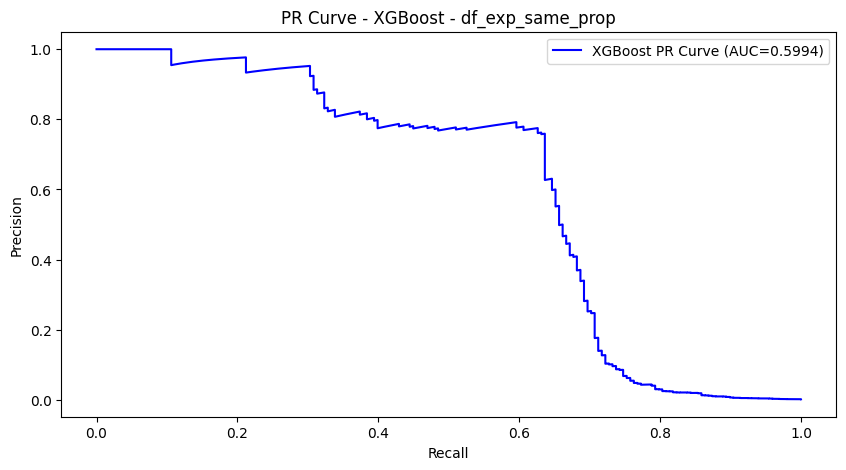


FINAL COMPARATIVE TABLE (Sorted by F2-Score)
         dataset  f1_fraude_opt  f2_fraude_opt  recall_at_f2_opt  precision_at_f2_opt   auc_pr  roc_auc  best_thresh_f2
       df_exp_50       0.688442       0.690524          0.691919             0.685000 0.625293 0.943810        0.949659
   df_exp_random       0.673629       0.660184          0.651515             0.697297 0.601228 0.929548        0.964421
df_exp_same_prop       0.692308       0.657620          0.636364             0.759036 0.599363 0.939014        0.969518
       df_exp_63       0.646465       0.646465          0.646465             0.646465 0.537260 0.933149        0.970426


In [23]:
# 1. Define the list of tuples (dataframe, name)
df_exp_50 = pd.read_csv("df_exp_50.csv")
df_exp_random = pd.read_csv("df_exp_random.csv")
df_exp_63 = pd.read_csv("df_exp_63.csv")
df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_random, 'df_exp_random'),
    (df_exp_63, 'df_exp_63'),
    (df_exp_same_prop, 'df_exp_same_prop')
]

# 2. List to accumulate results
results_list = []

for df_dataset, name_dataset in datasets_to_evaluate:
  metrics = eval_desbalanceado_xgboost(df_dataset, name_dataset)

  if metrics:
      results_list.append(metrics)


# Final Comparative Summary
if results_list:
    df_results = pd.DataFrame(results_list)

    # Key columns to show in the summary (prioritizing F2 and Recall)
    cols_to_show = [
        'dataset',
        'f1_fraude_opt',
        'f2_fraude_opt',
        'recall_at_f2_opt',
        'precision_at_f2_opt',
        'auc_pr',
        'roc_auc',
        'best_thresh_f2'
    ]
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("FINAL COMPARATIVE TABLE (Sorted by F2-Score)")
    print("="*80)

    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    print(summary_sorted.to_string(index=False))

else:
    print("No results generated to show.")

### Random Forest

In [22]:
# ============================================================================
# Detailed analysis with Random Forest for extreme imbalance
# ============================================================================
def eval_desbalanceado_rf(df_in: pd.DataFrame, name: str) -> dict:
    print(f"\n{'='*60}")
    print(f"Detailed analysis (Random Forest): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Initial selection of PCA variables (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No V1-V28 variables found; skipping.")
        return {}

    print(f"Available PCA variables: {len(available_pca_vars)} -> {available_pca_vars}")

    # Remove rows with NaN
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Temporal Split (Day 1 train, Day 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Only one day found; evaluation skipped.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Correlation Analysis
    # ---------------------------------------------------------------------
    print("\n=== PCA Variable Correlation Analysis ===")
    pca_only_train = train_df.loc[:, available_pca_vars]
    corr_matrix = pca_only_train.corr().abs()

    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Pairs with correlation >= {threshold_corr}: {len(high_corr_pairs)}")

    # Correlations with the target in TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    # ---------------------------------------------------------------------
    # 4) Remove highly correlated PCA variables
    # ---------------------------------------------------------------------
    vars_to_remove = set()

    for var1, var2, corr_val in high_corr_pairs:
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        c1 = abs(float(target_corr[var1]))
        c2 = abs(float(target_corr[var2]))

        if c1 >= c2:
            vars_to_remove.add(var2)
        else:
            vars_to_remove.add(var1)

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]
    print(f"Variables removed: {len(vars_to_remove)}")
    print(f"Final variables: {len(final_pca_vars)}")

    if not final_pca_vars:
        return {}

    # ---------------------------------------------------------------------
    # 5) Deduplicate and prepare X, y
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    # ---------------------------------------------------------------------
    # 6) Train Random Forest
    # ---------------------------------------------------------------------
    # class_weight='balanced' is vital here to replace scale_pos_weight logic
    model = RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    model.fit(X_train, y_train)

    # Predictions (probability of class 1)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Standard Metrics (Threshold 0.5)
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    tn, fp, fn, tp = cm_05.ravel()

    rec_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    # F1 and F2 Score
    f1_05 = 2 * (prec_05 * rec_05) / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print("\n--- Confusion Matrix (RF at 0.5) ---")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")
    print(f"F1 Score: {f1_05:.4f}")
    print(f"F2 Score: {f2_05:.4f}")

    # ---------------------------------------------------------------------
    # 8) Curves and AUC
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"AUC-PR: {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ---------------------------------------------------------------------
    # 9) Optimal Threshold (Maximize F2)
    # ---------------------------------------------------------------------
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):

        # Manually calculate F2 for each point on the curve
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    # Initialize
    best_thresh_f2 = 0.5
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0
    best_f1_score = 0.0
    best_f2_score = 0.0

    if scores_list:
        # Tuple: (thresh, prec, rec, f2) -> Index 3 is F2
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

        # Recalculate TP/FP for exact reporting with that threshold
        y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

        print(f"\n--- Optimal Threshold RF (Max F2) ---")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"F1 Score:  {best_f1_score:.4f}")
        print(f"F2 Score:  {best_f2_score:.4f}")
        print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
        print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")


    # ---------------------------------------------------------------------
    # 10) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'RF PR Curve (AUC={auc_pr:.4f})', color='green', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraud', density=True, color='skyblue')
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraud', density=True, color='orange')
    plt.axvline(x=0.5, color='red', linestyle='--', label='Thresh 0.5')
    plt.axvline(x=best_thresh_f2, color='green', linestyle=':', linewidth=2, label=f'Best F2 ({best_thresh_f2:.3f})')
    plt.xlabel('Probability (RF)')
    plt.title(f'Probability Distribution - {name}')
    plt.legend()
    plt.show()


    return {
        'dataset': name,
        'model': 'LightGBM_AllVars',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (Random Forest): df_exp_50
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 0
Variables removed: 0
Final variables: 15

--- Confusion Matrix (RF at 0.5) ---
TN: 135100 | FP: 34
FN: 65 | TP: 133
F1 Score: 0.7288
F2 Score: 0.6934
AUC-PR: 0.6963
ROC-AUC: 0.9545

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.2822
F1 Score:  0.7136
F2 Score:  0.7451
Precision: 0.6667 (FP: 76)
Recall:    0.7677 (TP: 152)


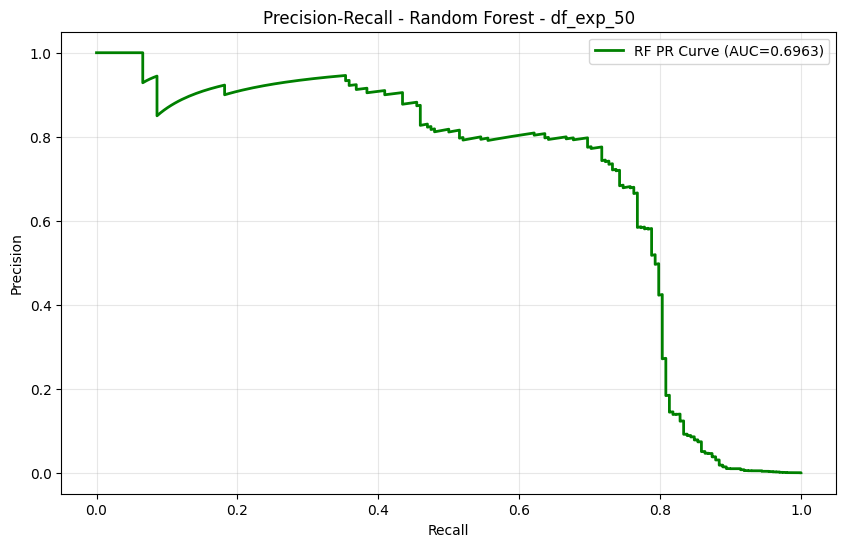

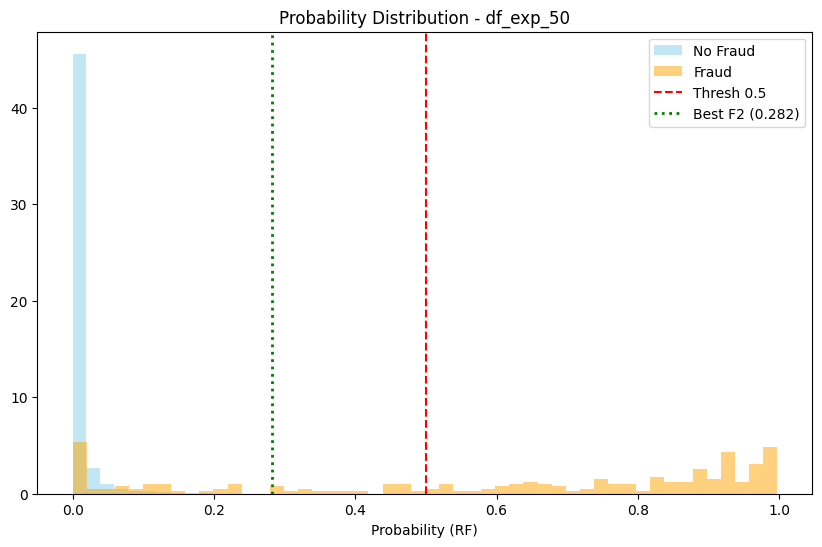


Detailed analysis (Random Forest): df_exp_random
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 0
Variables removed: 0
Final variables: 15

--- Confusion Matrix (RF at 0.5) ---
TN: 135103 | FP: 31
FN: 70 | TP: 128
F1 Score: 0.7171
F2 Score: 0.6730
AUC-PR: 0.7014
ROC-AUC: 0.9528

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.3049
F1 Score:  0.7327
F2 Score:  0.7415
Precision: 0.7184 (FP: 58)
Recall:    0.7475 (TP: 148)


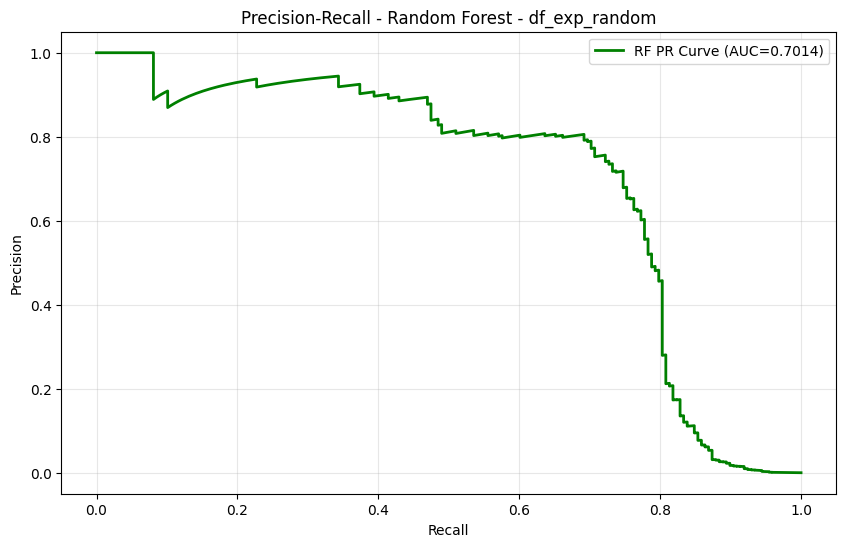

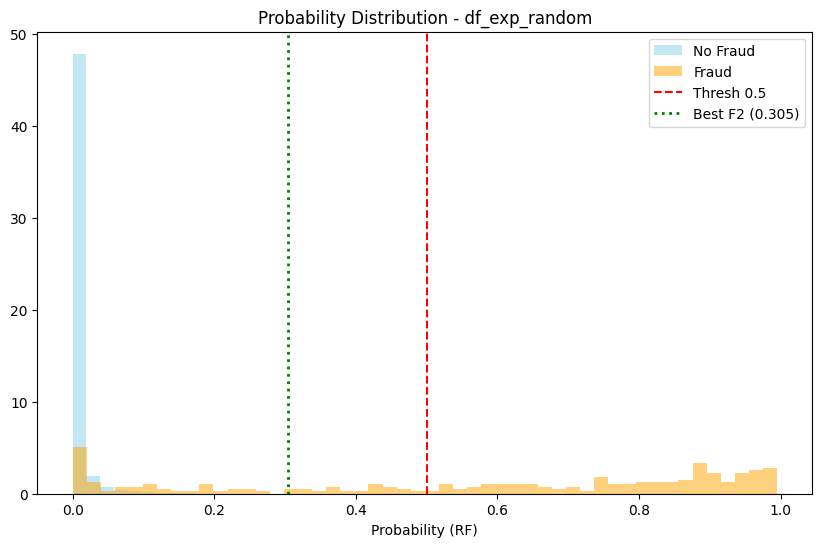


Detailed analysis (Random Forest): df_exp_63
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 1
Variables removed: 1
Final variables: 14

--- Confusion Matrix (RF at 0.5) ---
TN: 135087 | FP: 47
FN: 70 | TP: 128
F1 Score: 0.6863
F2 Score: 0.6618
AUC-PR: 0.6003
ROC-AUC: 0.9494

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.4253
F1 Score:  0.6853
F2 Score:  0.6832
Precision: 0.6888 (FP: 61)
Recall:    0.6818 (TP: 135)


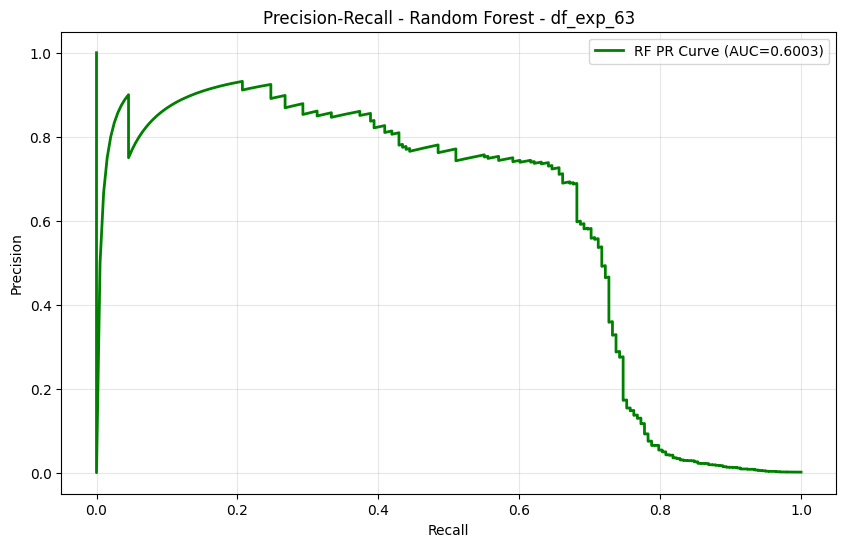

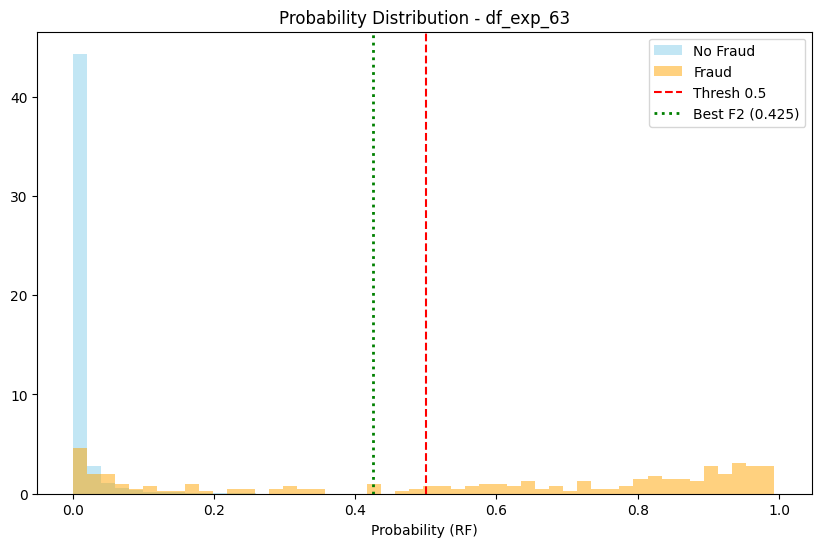


Detailed analysis (Random Forest): df_exp_same_prop
Available PCA variables: 15 -> ['V3', 'V6', 'V13', 'V14', 'V15', 'V17', 'V19', 'V20', 'V21', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 0
Variables removed: 0
Final variables: 15

--- Confusion Matrix (RF at 0.5) ---
TN: 135104 | FP: 30
FN: 70 | TP: 128
F1 Score: 0.7191
F2 Score: 0.6737
AUC-PR: 0.6959
ROC-AUC: 0.9544

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.2494
F1 Score:  0.7290
F2 Score:  0.7517
Precision: 0.6941 (FP: 67)
Recall:    0.7677 (TP: 152)


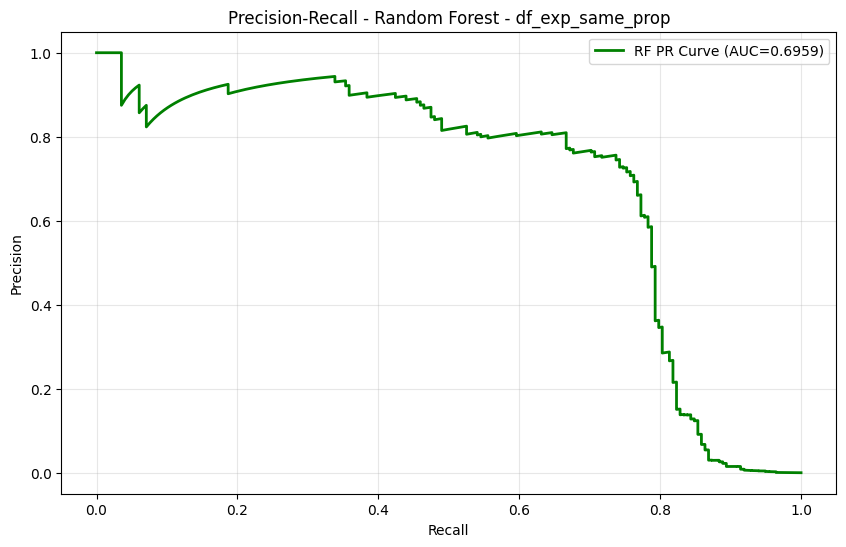

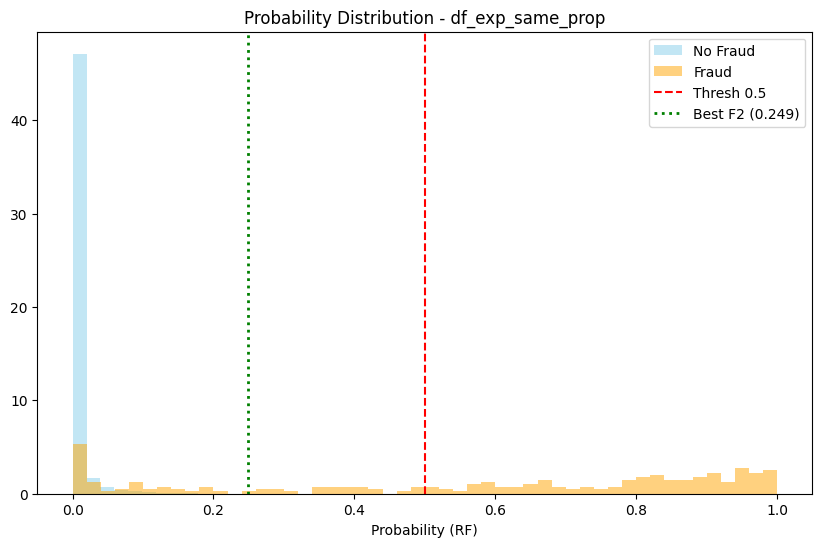


FINAL COMPARATIVE TABLE (Sorted by F2-Score)
         dataset  f1_fraude_opt  f2_fraude_opt  recall_at_f2_opt  precision_at_f2_opt   auc_pr  roc_auc  best_thresh_f2
df_exp_same_prop       0.729017       0.751731          0.767677             0.694064 0.695850 0.954380        0.249446
       df_exp_50       0.713615       0.745098          0.767677             0.666667 0.696270 0.954519        0.282163
   df_exp_random       0.732673       0.741483          0.747475             0.718447 0.701415 0.952800        0.304867
       df_exp_63       0.685279       0.683198          0.681818             0.688776 0.600321 0.949365        0.425317


In [24]:
# 1. Define the list of tuples (dataframe, name)
df_exp_50 = pd.read_csv("df_exp_50.csv")
df_exp_random = pd.read_csv("df_exp_random.csv")
df_exp_63 = pd.read_csv("df_exp_63.csv")
df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_random, 'df_exp_random'),
    (df_exp_63, 'df_exp_63'),
    (df_exp_same_prop, 'df_exp_same_prop')
]

# 2. List to accumulate results
results_list = []

for df_dataset, name_dataset in datasets_to_evaluate:
  metrics = eval_desbalanceado_rf(df_dataset, name_dataset)

  if metrics:
      results_list.append(metrics)


# Final Comparative Summary
if results_list:
    df_results = pd.DataFrame(results_list)

    # Key columns to show in the summary (prioritizing F2 and Recall)
    cols_to_show = [
        'dataset',
        'f1_fraude_opt',
        'f2_fraude_opt',
        'recall_at_f2_opt',
        'precision_at_f2_opt',
        'auc_pr',
        'roc_auc',
        'best_thresh_f2'
    ]
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("FINAL COMPARATIVE TABLE (Sorted by F2-Score)")
    print("="*80)

    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    print(summary_sorted.to_string(index=False))

else:
    print("No results generated to show.")

### Would the model improve by adding other variables for the selected dataframe?

In [ ]:
df = df_exp_same_prop.copy()
df1 = df_exp_random.copy()

In [ ]:
df.describe()

,V3,V6,V13,V14,V15,V17,V19,V20,V21,V23,...,secs_since_prev_tx,tx_per_customer,tx_rate,geo_anomaly,device_change,browser_change,shared_ip,amount_log,is_outlier_amount,Synthetic
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.248306,0.025240,-0.008887,-0.029473,0.098366,-0.022083,-0.003284,0.019338,-0.010969,-0.014292,...,592.940338,286.991468,0.386565,0.995890,0.709624,0.619646,0.000086,3.164869,0.113144,0.427864
std,1.623943,1.320584,0.997196,1.131676,0.926699,1.146989,0.819582,0.752855,0.799874,0.617355,...,874.668663,16.347525,0.319662,0.063977,0.453936,0.485474,0.009273,1.666820,0.316769,0.494770
min,-48.325589,-26.167270,-5.802082,-19.246859,-4.498945,-25.187909,-7.216086,-54.497720,-34.832916,-44.807735,...,-31.650439,238.450519,0.120603,0.000000,0.000000,0.000000,0.000000,-0.057274,0.000000,0.000000
25%,-0.400658,-0.726735,-0.661444,-0.397331,-0.477484,-0.457277,-0.476960,-0.194703,-0.227187,-0.167236,...,140.000000,276.000000,0.186351,1.000000,0.000000,0.000000,0.000000,1.894170,0.000000,0.000000
50%,0.462061,-0.235374,-0.017605,0.049327,0.177535,-0.048209,-0.001959,-0.045560,-0.043190,-0.027177,...,345.000000,287.000000,0.260643,1.000000,1.000000,1.000000,0.000000,3.161670,0.000000,0.000000
75%,1.199059,0.422087,0.654194,0.471235,0.769094,0.408790,0.471231,0.149469,0.156322,0.119375,...,714.187286,298.000000,0.445095,1.000000,1.000000,1.000000,0.000000,4.382027,0.000000,1.000000
max,9.382558,73.301626,7.126883,10.534299,8.877742,9.259642,5.591971,39.420904,27.219911,22.528412,...,19930.000000,335.452356,2.045184,1.000000,1.000000,1.000000,1.000000,10.153941,1.000000,1.000000


In [ ]:
df1.describe()

,V3,V6,V13,V14,V15,V17,V19,V20,V21,V23,...,secs_since_prev_tx,tx_per_customer,tx_rate,geo_anomaly,device_change,browser_change,shared_ip,amount_log,is_outlier_amount,Synthetic
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.249813,0.025833,-0.008877,-0.029154,0.097817,-0.022662,-0.003728,0.018690,-0.011339,-0.014341,...,592.720959,287.044573,0.387508,0.995892,0.709266,0.619346,0.000078,3.168551,0.113696,0.427864
std,1.624038,1.318215,0.998766,1.129838,0.926960,1.143829,0.819424,0.750414,0.789789,0.614514,...,871.471201,16.337201,0.320833,0.063962,0.454101,0.485548,0.008831,1.667387,0.317442,0.494770
min,-48.325589,-26.160506,-5.791881,-19.214325,-4.498945,-25.188247,-7.213527,-54.497720,-34.830382,-44.807735,...,-27.375592,238.508484,0.120125,0.000000,0.000000,0.000000,0.000000,-0.049578,0.000000,0.000000
25%,-0.398316,-0.726932,-0.661868,-0.397382,-0.478870,-0.457812,-0.478372,-0.194724,-0.227028,-0.167385,...,140.000000,276.000000,0.186486,1.000000,0.000000,0.000000,0.000000,1.902108,0.000000,0.000000
50%,0.463545,-0.233211,-0.017516,0.050002,0.178346,-0.049255,-0.003169,-0.045828,-0.043009,-0.027241,...,346.000000,287.000000,0.261318,1.000000,1.000000,1.000000,0.000000,3.167161,0.000000,0.000000
75%,1.201624,0.426678,0.656388,0.471538,0.769375,0.408159,0.470155,0.148747,0.156093,0.118877,...,716.000000,298.000000,0.450301,1.000000,1.000000,1.000000,0.000000,4.385986,0.000000,1.000000
max,9.388272,73.301626,7.126883,10.526766,8.877742,9.261316,5.591971,39.420904,27.217262,22.528412,...,19930.000000,335.461338,2.041620,1.000000,1.000000,1.000000,1.000000,10.153941,1.000000,1.000000


--- Temporal Split ---
Train Date: 2023-01-01
Test Date:  2023-01-02
Train shape: (359451, 54), Test shape: (140549, 54)


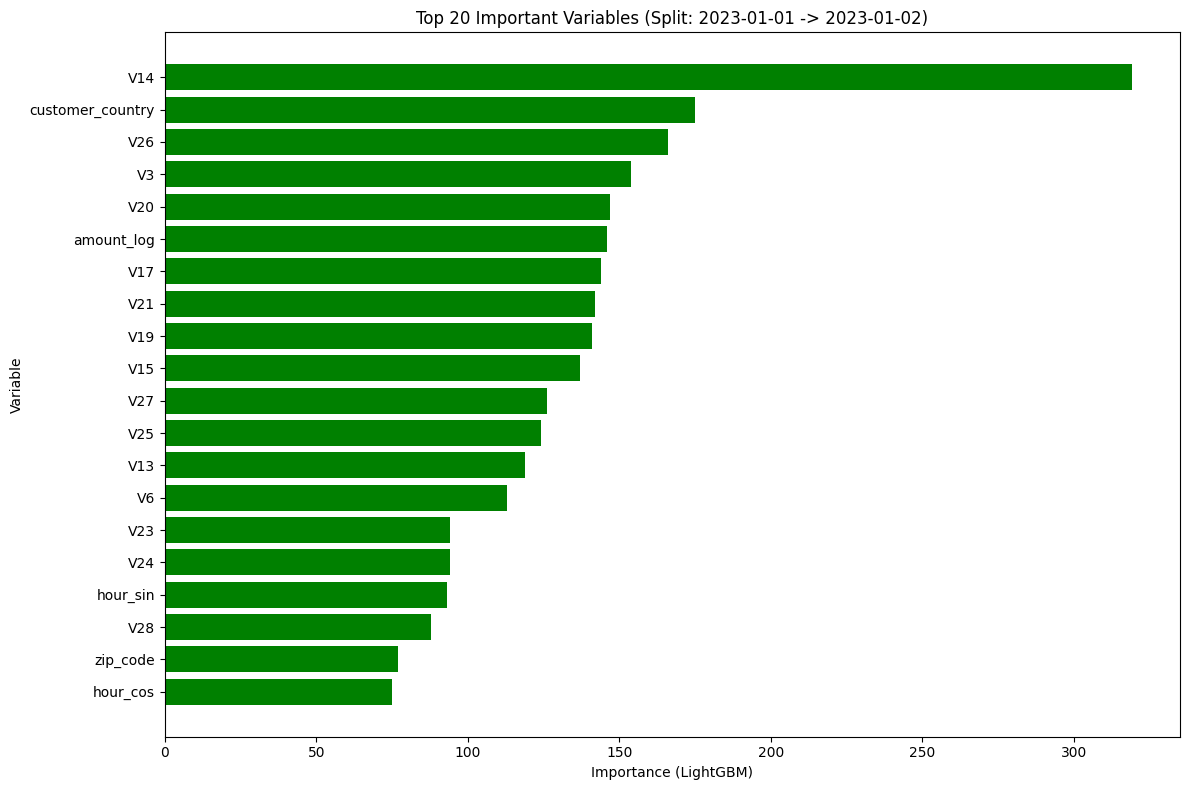

Vars: 1 | F2-score: 0.2202 | Recall: 0.8800 | AUC: 0.9304
Vars: 5 | F2-score: 0.6004 | Recall: 0.6795 | AUC: 0.8116
Vars: 10 | F2-score: 0.6057 | Recall: 0.6585 | AUC: 0.7808
Vars: 15 | F2-score: 0.7272 | Recall: 0.7296 | AUC: 0.8529
Vars: 20 | F2-score: 0.6747 | Recall: 0.7145 | AUC: 0.8648
Vars: 25 | F2-score: 0.6253 | Recall: 0.7040 | AUC: 0.8524
Vars: 30 | F2-score: 0.5942 | Recall: 0.7681 | AUC: 0.8989
Vars: 35 | F2-score: 0.5635 | Recall: 0.7506 | AUC: 0.8966
Vars: 40 | F2-score: 0.6185 | Recall: 0.7366 | AUC: 0.8700


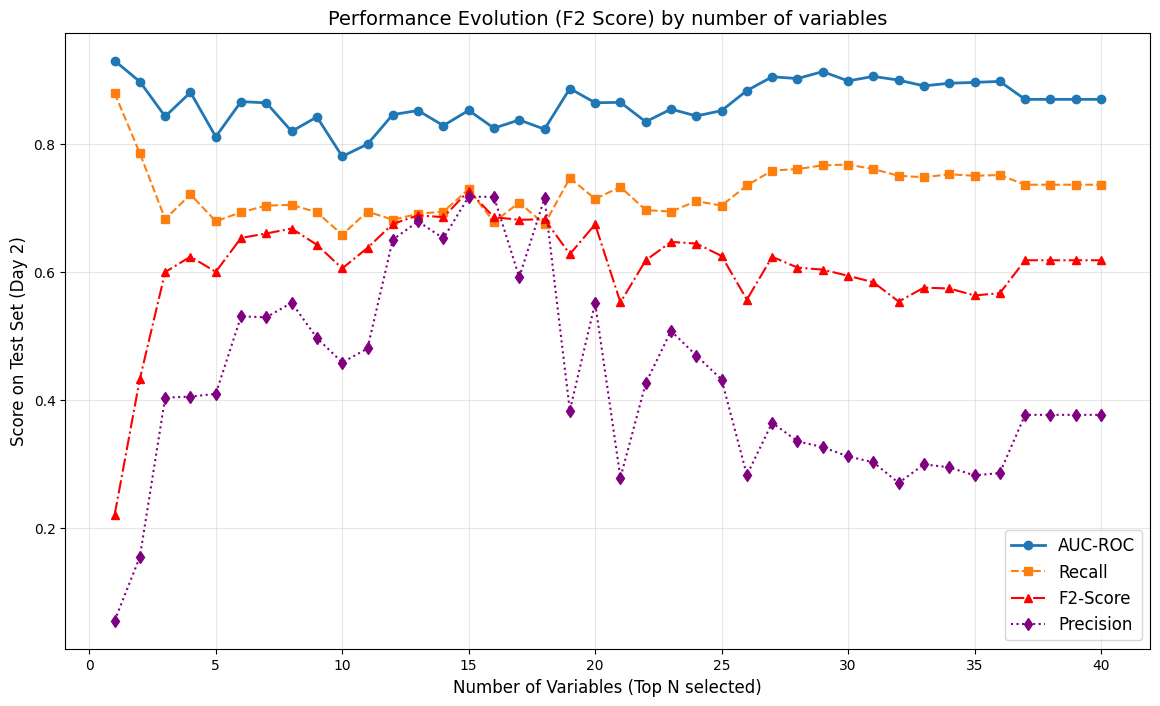

In [ ]:
#since datasets are similar, we only do this with one of them
import lightgbm as lgbm
# ============================================================================
# 1. Data Preparation with Temporal Split (Day 1 vs Day 2)
# ============================================================================

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['date'] = df['timestamp'].dt.date

# Identify available days
dates = sorted(df['date'].dropna().unique())

if len(dates) < 2:
    raise ValueError("The dataset needs at least 2 different days to perform this split.")

train_date = dates[0]
test_date = dates[1]

print(f"--- Temporal Split ---")
print(f"Train Date: {train_date}")
print(f"Test Date:  {test_date}")

# Create Train and Test DataFrames
train_df = df[df['date'] == train_date].copy()
test_df = df[df['date'] == test_date].copy()

# Define Columns to exclude (including those generated for the split)
TARGET_COLUMN = 'Class'
COLS_TO_EXCLUDE = [
    TARGET_COLUMN, 'transaction_id', 'customer_id', 'device_id',
    'email', 'phone', 'name', 'timestamp', 'date',
    'country_fraud_rate', "merchant_fraud_rate"
]

# Separate X and y
y_train = train_df[TARGET_COLUMN]
X_train = train_df.drop(columns=COLS_TO_EXCLUDE, errors='ignore')

y_test = test_df[TARGET_COLUMN]
X_test = test_df.drop(columns=COLS_TO_EXCLUDE, errors='ignore')

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Convert categorical variables to 'category' for LightGBM
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# ============================================================================
# 2. Train Base Model to obtain Importance Ranking
# ============================================================================

lgbm_base = lgbm.LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train, y_train)

# Create Importance DataFrame
importances = lgbm_base.feature_importances_
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features_LGBM = importance_df['Variable'].tolist()

# PLOT 1: Top 20 Feature Importances
top_20_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(
    top_20_features['Variable'],
    top_20_features['Importance'],
    color='green'
)
plt.xlabel("Importance (LightGBM)")
plt.ylabel("Variable")
plt.title(f"Top 20 Important Variables (Split: {train_date} -> {test_date})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# 3. Iterative Performance Evaluation (F2 Score)
# ============================================================================

metrics_results = {
    'num_vars': [],
    'auc': [],
    'recall': [],
    'f2': [],
    'precision': []
}

# Iterate over sorted features
# We know we won't use more than 40 variables, so we load up to 40
for k in range(1, 41, 1):

    # Select top k variables
    selected_feats = sorted_features_LGBM[:k]

    # Train new model with feature subset
    model_k = lgbm.LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model_k.fit(X_train[selected_feats], y_train)

    # Predict
    probs_test = model_k.predict_proba(X_test[selected_feats])[:, 1]
    preds_test = model_k.predict(X_test[selected_feats])

    # Calculate Metrics
    metrics_results['num_vars'].append(k)

    try:
        metrics_results['auc'].append(roc_auc_score(y_test, probs_test))
    except:
        metrics_results['auc'].append(0)

    metrics_results['recall'].append(recall_score(y_test, preds_test, zero_division=0))
    metrics_results['precision'].append(precision_score(y_test, preds_test, zero_division=0))

    # --- F2 CALCULATION ---
    # beta=2 prioritizes Recall over Precision
    f2_val = fbeta_score(y_test, preds_test, beta=2, zero_division=0)
    metrics_results['f2'].append(f2_val)

    # Progress Print with F2
    if k % 5 == 0 or k == 1:
        print(f"Vars: {k} | F2-score: {metrics_results['f2'][-1]:.4f} | Recall: {metrics_results['recall'][-1]:.4f} | AUC: {metrics_results['auc'][-1]:.4f}")

# PLOT 2: Performance Curve (With F2)
plt.figure(figsize=(14, 8))

plt.plot(metrics_results['num_vars'], metrics_results['auc'], label='AUC-ROC', marker='o', linewidth=2)
plt.plot(metrics_results['num_vars'], metrics_results['recall'], label='Recall', marker='s', linestyle='--')
# Plotting F2
plt.plot(metrics_results['num_vars'], metrics_results['f2'], label='F2-Score', marker='^', linestyle='-.', color='red')
plt.plot(metrics_results['num_vars'], metrics_results['precision'], label='Precision', marker='d', linestyle=':', color='purple')

plt.xlabel('Number of Variables (Top N selected)', fontsize=12)
plt.ylabel('Score on Test Set (Day 2)', fontsize=12)
plt.title('Performance Evolution (F2 Score) by number of variables', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print(sorted_features_LGBM)

['V14', 'customer_country', 'V26', 'V3', 'V20', 'amount_log', 'V17', 'V21', 'V19', 'V15', 'V27', 'V25', 'V13', 'V6', 'V23', 'V24', 'hour_sin', 'V28', 'zip_code', 'hour_cos', 'merchant', 'age', 'Amount', 'secs_since_prev_tx', 'credit_score', 'city', 'tx_per_customer', 'tx_rate', 'morning', 'days_in_bank', 'days_in_bank_log', 'afternoon', 'evening', 'main_browser', 'is_night_tx', 'browser_change', 'is_mobile', 'ip_address', 'is_foreign_tx', 'merchant_country', 'is_weekend', 'device_type', 'time_of_day', 'browser', 'os', 'is_high_amount', 'night', 'tenure_bucket', 'geo_anomaly', 'main_device', 'device_change', 'shared_ip', 'is_outlier_amount', 'Synthetic']


Adding the new variables to see how the model improves

In [8]:
variables_pca = [f'V{i}' for i in range(1, 29)]
variables_especificas = [ 'customer_country', 'amount_log', 'timestamp']
VARIABLES_TO_KEEP = list(set(variables_especificas + variables_pca + ['Class']))

In [9]:
print(VARIABLES_TO_KEEP)

In [11]:
columnas_existentes = [c for c in VARIABLES_TO_KEEP if c in df_exp_same_prop.columns]

In [12]:
df_same_prop_new = df_exp_same_prop[columnas_existentes].copy()

In [ ]:
df_random_new = df_exp_random[columnas_existentes].copy()

## Models with extreme imbalance

### LightGBM

In [6]:
def eval_desbalanceado_lgbm_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using LIGHTGBM with metrics for extreme imbalance (F2)
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (LightGBM - All variables): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection (Pre-encoding cleanup)
    # ---------------------------------------------------------------------

    # Define columns NOT to include in get_dummies (Metadata and Target)
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    # Filter to drop only those existing in current DF
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    # X_raw must only contain predictive variables (numeric or categorical)
    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables before encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Preprocessing: One-Hot Encoding
    # ---------------------------------------------------------------------
    # Apply dummies only to predictive variables
    X_processed = pd.get_dummies(X_raw, drop_first=True)

    print(f"Variables after Encoding: {X_processed.shape[1]}")

    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split (Day 1 train, Day 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 different days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    # Separate Train and Test using the date
    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    # When creating X_train/X_test, drop the temporal reference column
    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning
    # ---------------------------------------------------------------------
    print("\n=== Correlation Analysis (All vars) ===")

    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.90

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    print(f"Variables removed due to high correlation (> {threshold_corr}): {len(to_drop_corr)}")

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    print(f"Final variables for the model: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Train LightGBM
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Metrics and Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Search for best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    best_thresh_f2 = 0.5
    best_prec_f2 = 0.0
    best_rec_f2 = 0.0
    best_f1_score = 0.0
    best_f2_score = 0.0


    if scores_list:
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

    # Recalculate matrix for optimal
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f1_05 = 2 * (prec_05 * rec_05) / ((prec_05) + rec_05) if ((prec_05) + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F1: {f1_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold (Maximizes F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F1 Score:  {best_f1_score:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")

    # ---------------------------------------------------------------------
    # 7) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'PR Curve (AUC={auc_pr:.4f})', color='purple', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - LightGBM - {name}')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraud', density=True, color='skyblue')
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraud', density=True, color='orange')
    plt.axvline(x=best_thresh_f2, color='blue', linestyle=':', linewidth=2, label=f'Opt F2 ({best_thresh_f2:.3f})')
    plt.legend()
    plt.show()

    return {
        'dataset': name,
        'model': 'LightGBM_AllVars',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (LightGBM - All variables): df_random_new
Variables before encoding: 17
Variables after Encoding: 251
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (All vars) ===
Variables removed due to high correlation (> 0.9): 0
Final variables for the model: 251

AUC-PR:  0.7886
ROC-AUC: 0.9607

--- Threshold 0.5 ---
Recall: 0.7168 | F1: 0.7849 | F2: 0.7426

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.0333
F1 Score:  0.7976
F2 Score:  0.7803
Precision: 0.8281 (FP: 137)
Recall:    0.7692 (TP: 660)


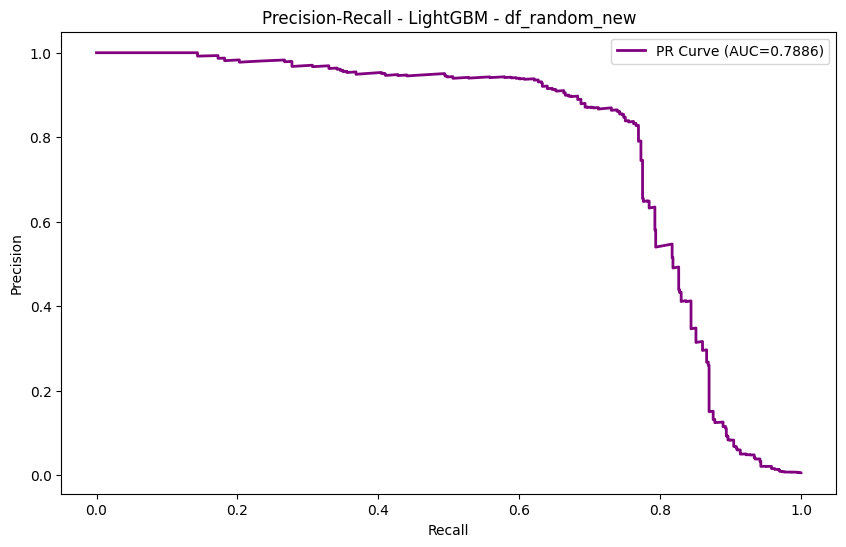

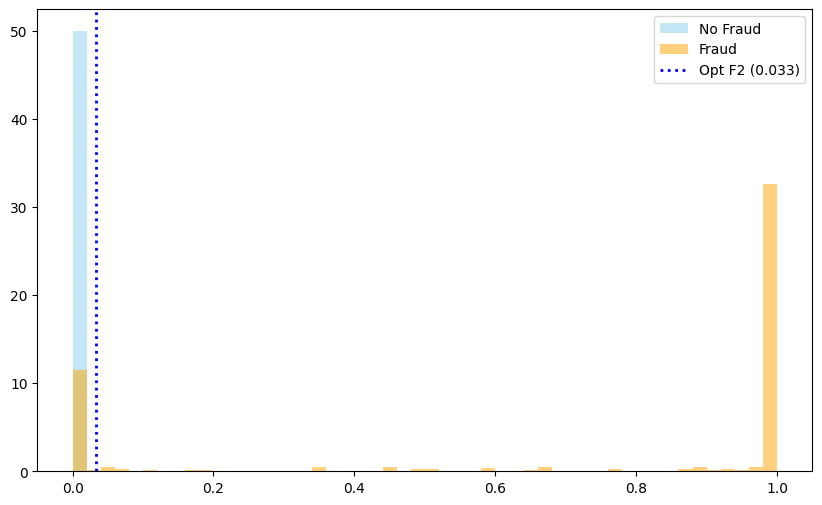

{'dataset': 'df_random_new',
 'model': 'LightGBM_AllVars',
 'best_thresh_f2': np.float64(0.03325374403501544),
 'auc_pr': np.float64(0.7885773667154709),
 'roc_auc': np.float64(0.9606979951203989),
 'f1_fraude_05': np.float64(0.7849393746011486),
 'f2_fraude_05': np.float64(0.7425742574257426),
 'f1_fraude_opt': np.float64(0.797583081570997),
 'f2_fraude_opt': np.float64(0.7803263182785529),
 'precision_at_f2_opt': np.float64(0.8281053952321205),
 'recall_at_f2_opt': np.float64(0.7692307692307693),
 'fraudes_totales': 858}

In [16]:
eval_desbalanceado_lgbm_all_vars(df_random_new, "df_random_new")


Detailed analysis (LightGBM - All variables): df_same_prop_new
Variables before encoding: 17
Variables after Encoding: 251
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (All vars) ===
Variables removed due to high correlation (> 0.9): 0
Final variables for the model: 251

AUC-PR:  0.8012
ROC-AUC: 0.9600

--- Threshold 0.5 ---
Recall: 0.7168 | F1: 0.7971 | F2: 0.7469

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.0203
F1 Score:  0.8220
F2 Score:  0.8034
Precision: 0.8552 (FP: 115)
Recall:    0.7914 (TP: 679)


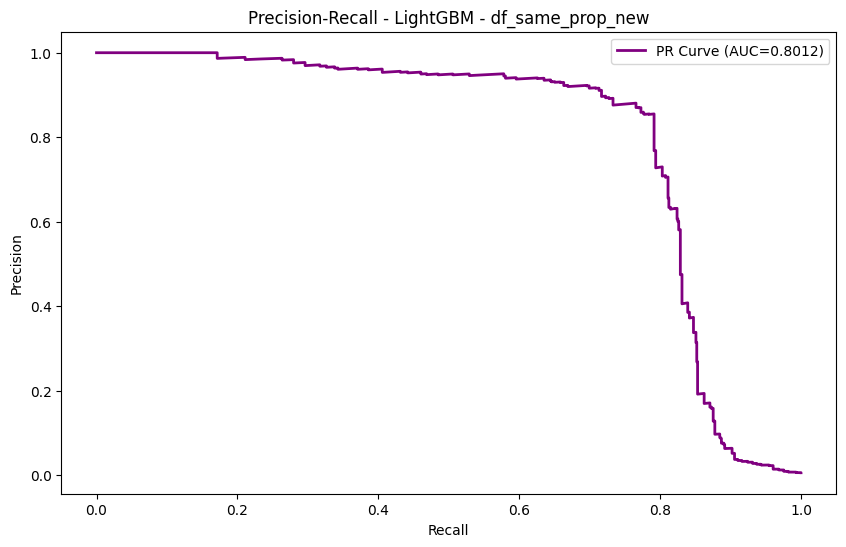

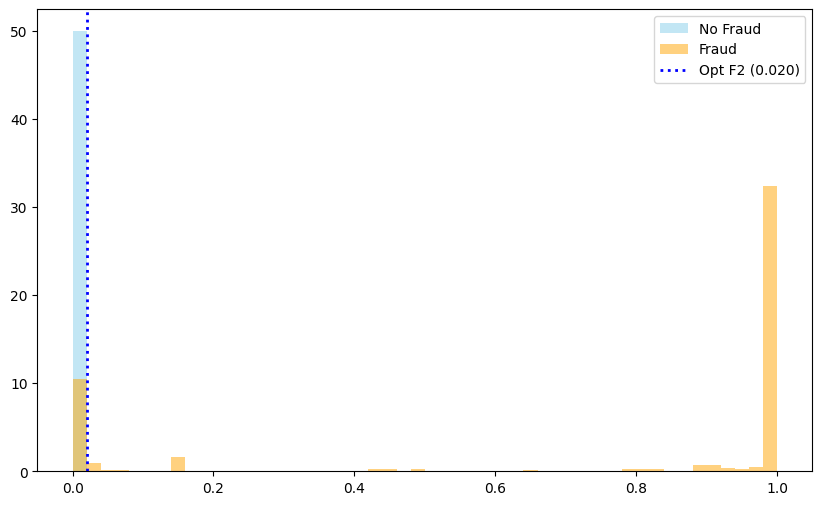

{'dataset': 'df_same_prop_new',
 'model': 'LightGBM_AllVars',
 'best_thresh_f2': np.float64(0.020278369773282342),
 'auc_pr': np.float64(0.8012421907545992),
 'roc_auc': np.float64(0.9599705987769642),
 'f1_fraude_05': np.float64(0.7971484121840571),
 'f2_fraude_05': np.float64(0.746903084770464),
 'f1_fraude_opt': np.float64(0.8220338983050848),
 'f2_fraude_opt': np.float64(0.8033601514434453),
 'precision_at_f2_opt': np.float64(0.8551637279596978),
 'recall_at_f2_opt': np.float64(0.7913752913752914),
 'fraudes_totales': 858}

In [15]:
eval_desbalanceado_lgbm_all_vars(df_same_prop_new, "df_same_prop_new")

### CatBoost

In [26]:
def eval_desbalanceado_catboost_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using CATBOOST with metrics for extreme imbalance.
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (CatBoost - Native): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    # ---------------------------------------------------------------------
    # 2) Identification of Categoricals (No One-Hot Encoding)
    # ---------------------------------------------------------------------

    cat_features_indices = []
    cat_features_names = []

    for col in X_raw.columns:
        # If it is object or category, treat it as categorical
        if X_raw[col].dtype == 'object' or X_raw[col].dtype.name == 'category':
            cat_features_names.append(col)
            # Fill categorical nulls to avoid errors
            X_raw[col] = X_raw[col].astype(str).fillna("MISSING")

    print(f"Total variables: {X_raw.shape[1]}")
    print(f"Categorical variables detected: {len(cat_features_names)}")

    # Add temporal reference for the split
    X_raw['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_raw['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 different days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_raw['date_split_ref'] == train_date
    mask_test = X_raw['date_split_ref'] == test_date

    X_train = X_raw[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_raw[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning (Numeric Only)
    # ---------------------------------------------------------------------

    print("\n=== Correlation Analysis (Numeric Variables) ===")

    # Select only numerics for the corr matrix
    X_train_num = X_train.select_dtypes(include=[np.number])

    if not X_train_num.empty:
        corr_matrix = X_train_num.corr().abs()
        threshold_corr = 0.90

        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

        print(f"Numeric variables removed due to high correlation: {len(to_drop_corr)}")

        X_train = X_train.drop(columns=to_drop_corr)
        X_test = X_test.drop(columns=to_drop_corr)

        cat_features_names = [c for c in cat_features_names if c in X_train.columns]
    else:
        print("No numeric variables to analyze for correlation.")

    print(f"Final variables for the model: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Train CatBoost
    # ---------------------------------------------------------------------
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0, # Silent
        allow_writing_files=False
    )

    model.fit(X_train, y_train, cat_features=cat_features_names)

    # --- SAVE THE MODEL ---
    filename = f"catboost_model_{name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved successfully as: {filename}")

    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Metrics and Thresholds
    # ---------------------------------------------------------------------

    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Search for best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    best_thresh_f2 = 0.5
    best_prec_f2 = 0.0
    best_rec_f2 = 0.0
    best_f1_score = 0.0
    best_f2_score = 0.0


    if scores_list:
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

    # Recalculate matrix for optimal
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f1_05 = 2 * (prec_05 * rec_05) / ((prec_05) + rec_05) if ((prec_05) + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F1: {f1_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold (Maximizes F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F1 Score:  {best_f1_score:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")

    # ---------------------------------------------------------------------
    # 7) Plots and Importance
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'CatBoost PR Curve (AUC={auc_pr:.4f})', color='darkorange', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - CatBoost - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Feature Importance
    importances = model.get_feature_importance()
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='brown')
    plt.title("Top 10 Important Variables (CatBoost)")
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'dataset': name,
        'model': 'CatBoost_AllVars',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (CatBoost - Native): df_random_new
Total variables: 17
Categorical variables detected: 1
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (Numeric Variables) ===
Numeric variables removed due to high correlation: 0
Final variables for the model: 17
Model saved successfully as: catboost_model_df_random_new.pkl

AUC-PR:  0.7689
ROC-AUC: 0.9343

--- Threshold 0.5 ---
Recall: 0.7564 | F1: 0.7490 | F2: 0.7534

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.6025
F1 Score:  0.7886
F2 Score:  0.7690
Precision: 0.8236 (FP: 139)
Recall:    0.7564 (TP: 649)


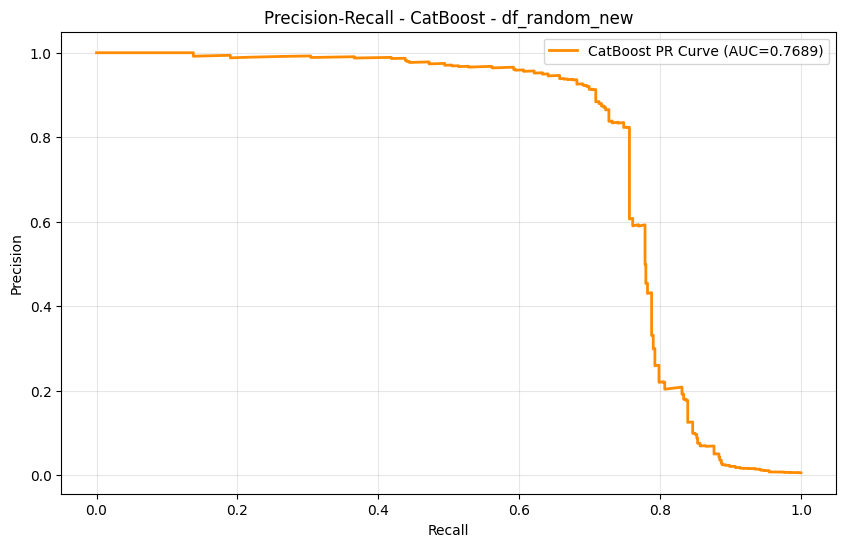

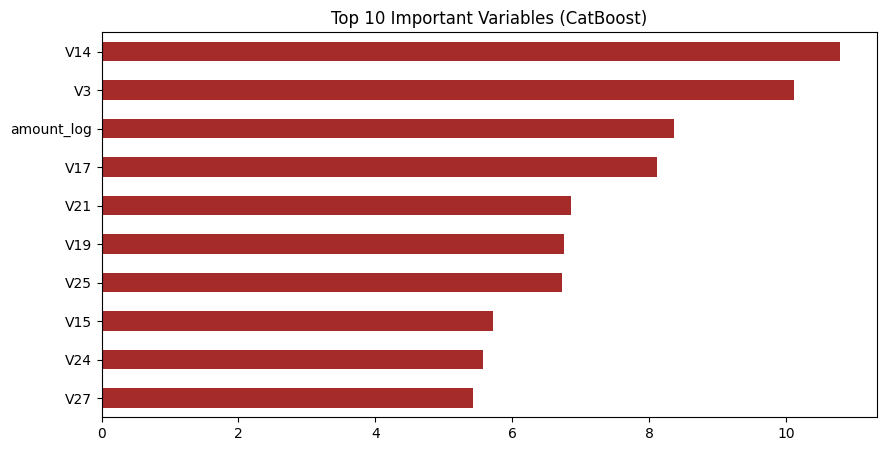

{'dataset': 'df_random_new',
 'model': 'CatBoost_AllVars',
 'best_thresh_f2': np.float64(0.6025428726281723),
 'auc_pr': np.float64(0.7689486140311963),
 'roc_auc': np.float64(0.9342862373945264),
 'f1_fraude_05': np.float64(0.7489901904212349),
 'f2_fraude_05': np.float64(0.7534246575342466),
 'f1_fraude_opt': np.float64(0.7885783718104497),
 'f2_fraude_opt': np.float64(0.7689573459715641),
 'precision_at_f2_opt': np.float64(0.8236040609137056),
 'recall_at_f2_opt': np.float64(0.7564102564102564),
 'fraudes_totales': 858}

In [28]:
eval_desbalanceado_catboost_all_vars(df_random_new, "df_random_new")


Detailed analysis (CatBoost - Native): df_same_prop_new
Total variables: 17
Categorical variables detected: 1
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (Numeric Variables) ===
Numeric variables removed due to high correlation: 0
Final variables for the model: 17
Model saved successfully as: catboost_model_df_same_prop_new.pkl

AUC-PR:  0.7746
ROC-AUC: 0.9272

--- Threshold 0.5 ---
Recall: 0.7634 | F1: 0.7854 | F2: 0.7720

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.6827
F1 Score:  0.8179
F2 Score:  0.7799
Precision: 0.8903 (FP: 80)
Recall:    0.7564 (TP: 649)


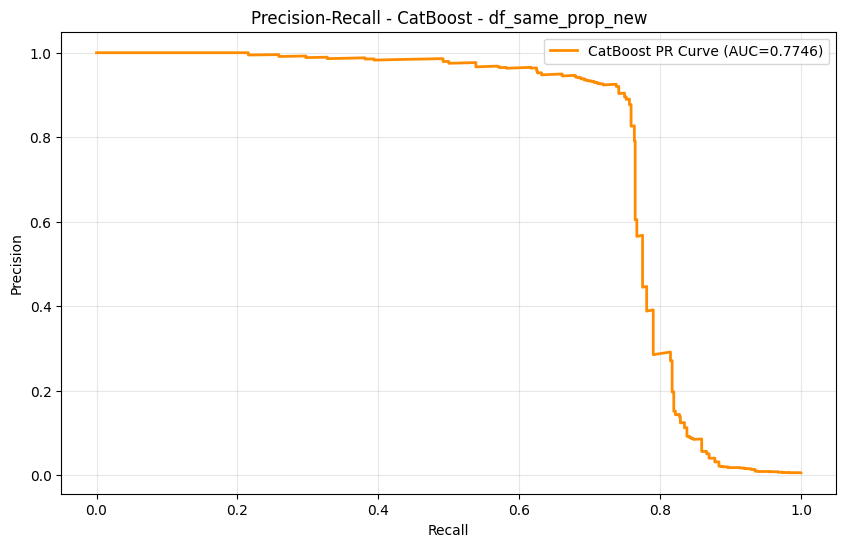

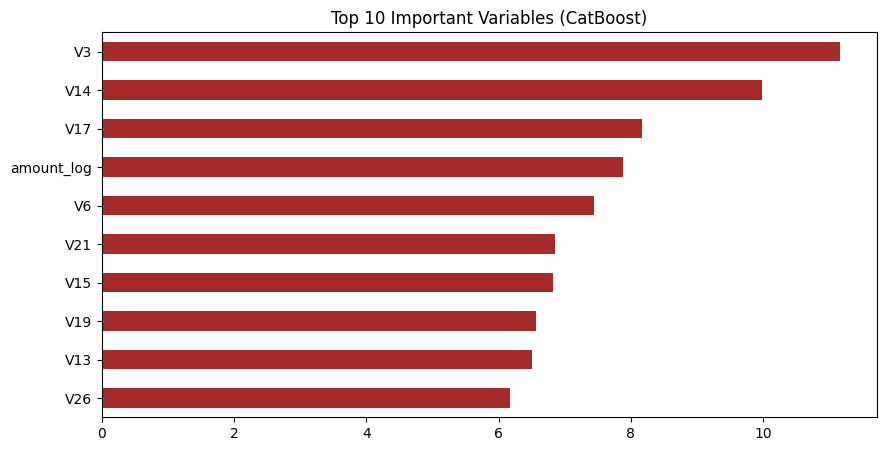

{'dataset': 'df_same_prop_new',
 'model': 'CatBoost_AllVars',
 'best_thresh_f2': np.float64(0.6826520052155056),
 'auc_pr': np.float64(0.7746459323109892),
 'roc_auc': np.float64(0.9271865513892559),
 'f1_fraude_05': np.float64(0.7853717026378896),
 'f2_fraude_05': np.float64(0.772041489863272),
 'f1_fraude_opt': np.float64(0.8178954001260239),
 'f2_fraude_opt': np.float64(0.7798606104301848),
 'precision_at_f2_opt': np.float64(0.8902606310013718),
 'recall_at_f2_opt': np.float64(0.7564102564102564),
 'fraudes_totales': 858}

In [27]:
eval_desbalanceado_catboost_all_vars(df_same_prop_new, "df_same_prop_new")

### XGBoost

In [19]:
def eval_desbalanceado_xgboost_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using XGBOOST with metrics for extreme imbalance.
    Adapted from CatBoost implementation.
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (XGBoost - Native): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    # ---------------------------------------------------------------------
    # 2) Identification of Categoricals (XGBoost Category Dtype)
    # ---------------------------------------------------------------------
    cat_features_names = []

    for col in X_raw.columns:
        # XGBoost requires 'category' dtype for native categorical support
        if X_raw[col].dtype == 'object' or X_raw[col].dtype.name == 'category':
            cat_features_names.append(col)
            # Fill nulls and convert to category
            X_raw[col] = X_raw[col].fillna("MISSING").astype('category')

    print(f"Total variables: {X_raw.shape[1]}")
    print(f"Categorical variables detected: {len(cat_features_names)}")

    # Add temporal reference for the split
    X_raw['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_raw['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 different days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_raw['date_split_ref'] == train_date
    mask_test = X_raw['date_split_ref'] == test_date

    X_train = X_raw[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_raw[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning (Numeric Only)
    # ---------------------------------------------------------------------
    print("\n=== Correlation Analysis (Numeric Variables) ===")
    X_train_num = X_train.select_dtypes(include=[np.number])

    if not X_train_num.empty:
        corr_matrix = X_train_num.corr().abs()
        threshold_corr = 0.90
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

        print(f"Numeric variables removed due to high correlation: {len(to_drop_corr)}")
        X_train = X_train.drop(columns=to_drop_corr)
        X_test = X_test.drop(columns=to_drop_corr)
    else:
        print("No numeric variables to analyze for correlation.")

    print(f"Final variables for the model: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Train XGBoost
    # ---------------------------------------------------------------------
    # Calculate scale_pos_weight (Ratio of negative to positive)
    count_neg = np.sum(y_train == 0)
    count_pos = np.sum(y_train == 1)
    ratio = count_neg / count_pos if count_pos > 0 else 1

    model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        objective='binary:logistic',
        scale_pos_weight=ratio,      # Equivalent to 'auto_class_weights'
        enable_categorical=True,     # Use native categorical support
        tree_method='hist',          # Faster and required for categorical data
        random_state=42,
        verbosity=0
    )

    model.fit(X_train, y_train)

    # --- SAVE THE MODEL ---
    filename = f"xgboost_model_{name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved successfully as: {filename}")

    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Metrics and Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = 0.5, 0.0, 0.0, 0.0, 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f1_05 = 2 * (prec_05 * rec_05) / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F1: {f1_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold (Maximizes F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F1 Score:  {best_f1_score:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")

    # ---------------------------------------------------------------------
    # 7) Plots and Importance
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'XGBoost PR Curve (AUC={auc_pr:.4f})', color='blue', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - XGBoost - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Feature Importance
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='navy')
    plt.title("Top 10 Important Variables (XGBoost)")
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'dataset': name,
        'model': 'XGBoost_AllVars',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (XGBoost - Native): df_random_new
Total variables: 17
Categorical variables detected: 1
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (Numeric Variables) ===
Numeric variables removed due to high correlation: 0
Final variables for the model: 17
Model saved successfully as: xgboost_model_df_random_new.pkl

AUC-PR:  0.7624
ROC-AUC: 0.9673

--- Threshold 0.5 ---
Recall: 0.7110 | F1: 0.7856 | F2: 0.7390

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.2654
F1 Score:  0.7830
F2 Score:  0.7501
Precision: 0.8448 (FP: 115)
Recall:    0.7296 (TP: 626)


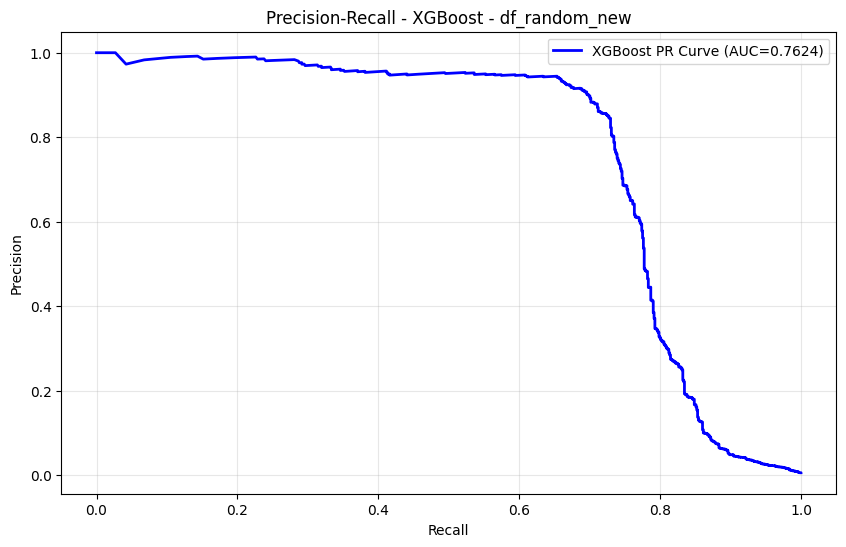

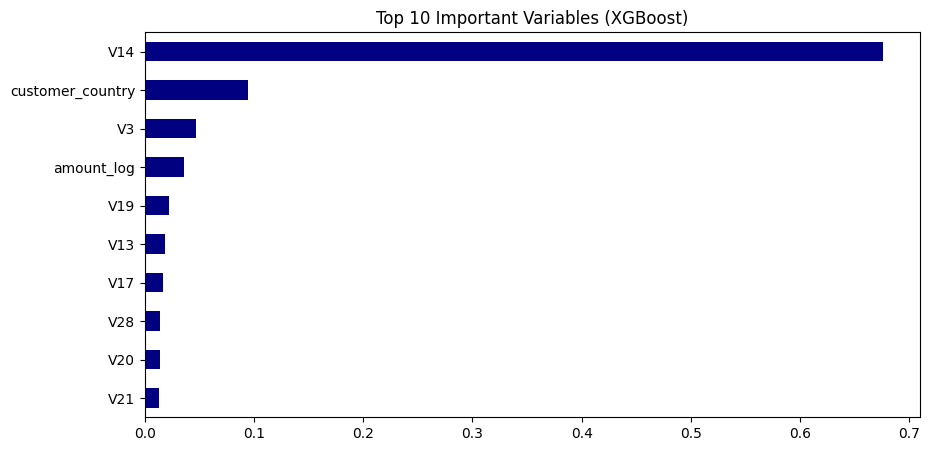

{'dataset': 'df_random_new',
 'model': 'XGBoost_AllVars',
 'best_thresh_f2': np.float32(0.2654209),
 'auc_pr': np.float64(0.7623948057507287),
 'roc_auc': np.float64(0.9672946936711245),
 'f1_fraude_05': np.float64(0.7855763039278816),
 'f2_fraude_05': np.float64(0.7390356190937727),
 'f1_fraude_opt': np.float64(0.782989368355222),
 'f2_fraude_opt': np.float64(0.7500599089384137),
 'precision_at_f2_opt': np.float64(0.844804318488529),
 'recall_at_f2_opt': np.float64(0.7296037296037297),
 'fraudes_totales': 858}

In [20]:
eval_desbalanceado_xgboost_all_vars(df_random_new, "df_random_new")


Detailed analysis (XGBoost - Native): df_same_prop_new
Total variables: 17
Categorical variables detected: 1
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (Numeric Variables) ===
Numeric variables removed due to high correlation: 0
Final variables for the model: 17
Model saved successfully as: xgboost_model_df_same_prop_new.pkl

AUC-PR:  0.7683
ROC-AUC: 0.9692

--- Threshold 0.5 ---
Recall: 0.7168 | F1: 0.7885 | F2: 0.7438

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.1957
F1 Score:  0.7717
F2 Score:  0.7589
Precision: 0.7941 (FP: 167)
Recall:    0.7506 (TP: 644)


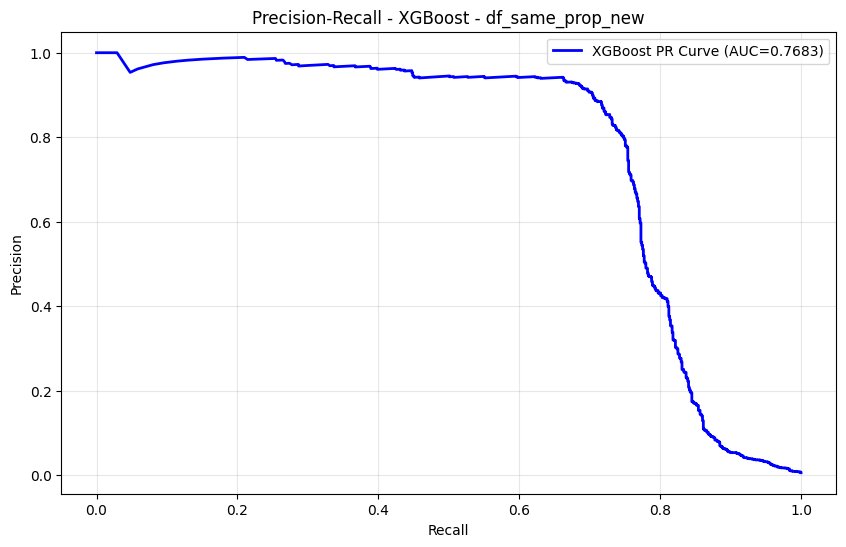

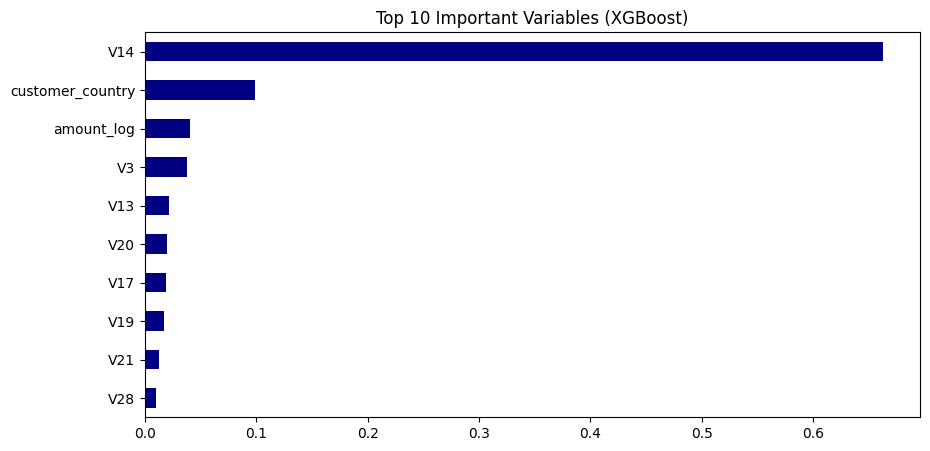

{'dataset': 'df_same_prop_new',
 'model': 'XGBoost_AllVars',
 'best_thresh_f2': np.float32(0.19572507),
 'auc_pr': np.float64(0.7682853699347367),
 'roc_auc': np.float64(0.9691679799632352),
 'f1_fraude_05': np.float64(0.7884615384615384),
 'f2_fraude_05': np.float64(0.7438316400580551),
 'f1_fraude_opt': np.float64(0.7717195925704016),
 'f2_fraude_opt': np.float64(0.7588970068347867),
 'precision_at_f2_opt': np.float64(0.7940813810110974),
 'recall_at_f2_opt': np.float64(0.7505827505827506),
 'fraudes_totales': 858}

In [21]:
eval_desbalanceado_xgboost_all_vars(df_same_prop_new, "df_same_prop_new")

### Random Forest

In [18]:
def eval_desbalanceado_rf_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using RANDOM FOREST with metrics for extreme imbalance.
    Saves the trained model to a .pkl file.
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (RF - All variables): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables before encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Preprocessing: One-Hot Encoding
    # ---------------------------------------------------------------------
    X_processed = pd.get_dummies(X_raw, drop_first=True)
    print(f"Variables after Encoding: {X_processed.shape[1]}")

    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 distinct days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning
    # ---------------------------------------------------------------------
    print("\n=== Correlation Analysis (All vars) ===")
    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.75
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    print(f"Final variables for the model: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Train Random Forest
    # ---------------------------------------------------------------------
    model = RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    model.fit(X_train, y_train)

    # --- SAVE THE MODEL ---
    filename = f"rf_model_{name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved successfully as: {filename}")
    # ----------------------

    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Metrics and Thresholds
    # ---------------------------------------------------------------------

    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Search for best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    best_thresh_f2 = 0.5
    best_prec_f2 = 0.0
    best_rec_f2 = 0.0
    best_f1_score = 0.0
    best_f2_score = 0.0


    if scores_list:
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

    # Recalculate matrix for optimal
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f1_05 = 2 * (prec_05 * rec_05) / ((prec_05) + rec_05) if ((prec_05) + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F1: {f1_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold (Maximizes F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F1 Score:  {best_f1_score:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")


    # ---------------------------------------------------------------------
    # 7) Plots and Importance
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'RF PR Curve (AUC={auc_pr:.4f})', color='green', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

        plt.figure(figsize=(10, 5))
        feat_imp.plot(kind='barh', color='teal')
        plt.title("Top 10 Important Variables (RF)")
        plt.gca().invert_yaxis()
        plt.show()

    return {
        'dataset': name,
        'model': 'RandomForest_AllVars',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (RF - All variables): df_random_new
Variables before encoding: 17
Variables after Encoding: 251
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (All vars) ===
Final variables for the model: 251
Model saved successfully as: rf_model_df_random_new.pkl

AUC-PR:  0.7831
ROC-AUC: 0.9634

--- Threshold 0.5 ---
Recall: 0.6795 | F1: 0.7884 | F2: 0.7192

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.3766
F1 Score:  0.8035
F2 Score:  0.7767
Precision: 0.8523 (FP: 113)
Recall:    0.7599 (TP: 652)


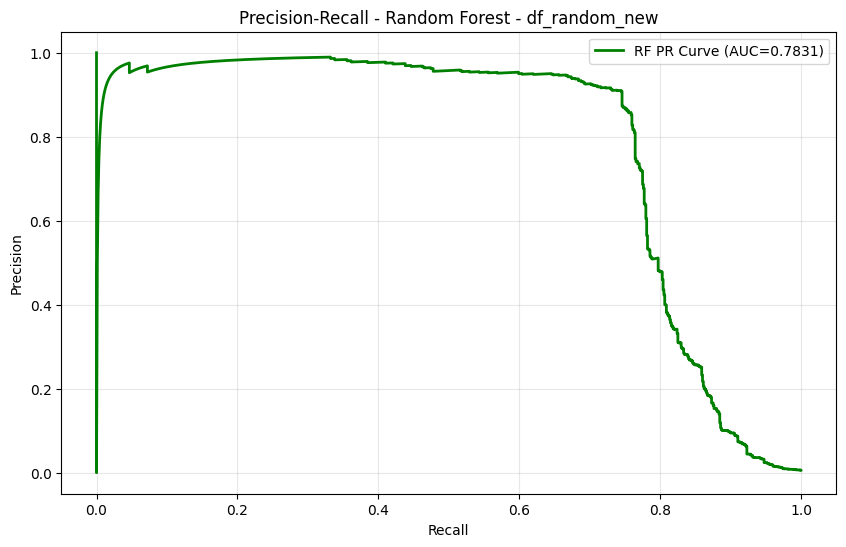

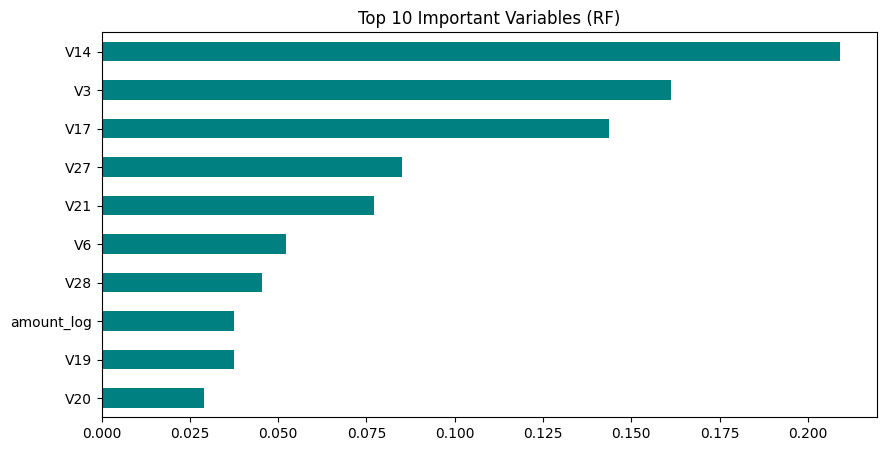

{'dataset': 'df_random_new',
 'model': 'RandomForest_AllVars',
 'best_thresh_f2': np.float64(0.37657334329452075),
 'auc_pr': np.float64(0.7830624123969702),
 'roc_auc': np.float64(0.9634222480289871),
 'f1_fraude_05': np.float64(0.7883705206220419),
 'f2_fraude_05': np.float64(0.7192203306192944),
 'f1_fraude_opt': np.float64(0.8034504004929145),
 'f2_fraude_opt': np.float64(0.7767452942578033),
 'precision_at_f2_opt': np.float64(0.8522875816993464),
 'recall_at_f2_opt': np.float64(0.7599067599067599),
 'fraudes_totales': 858}

In [20]:
eval_desbalanceado_rf_all_vars(df_random_new, "df_random_new")


Detailed analysis (RF - All variables): df_same_prop_new
Variables before encoding: 17
Variables after Encoding: 251
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (All vars) ===
Final variables for the model: 251
Model saved successfully as: rf_model_df_same_prop_new.pkl

AUC-PR:  0.7971
ROC-AUC: 0.9678

--- Threshold 0.5 ---
Recall: 0.6911 | F1: 0.7960 | F2: 0.7296

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.3832
F1 Score:  0.8125
F2 Score:  0.7867
Precision: 0.8596 (FP: 108)
Recall:    0.7704 (TP: 661)


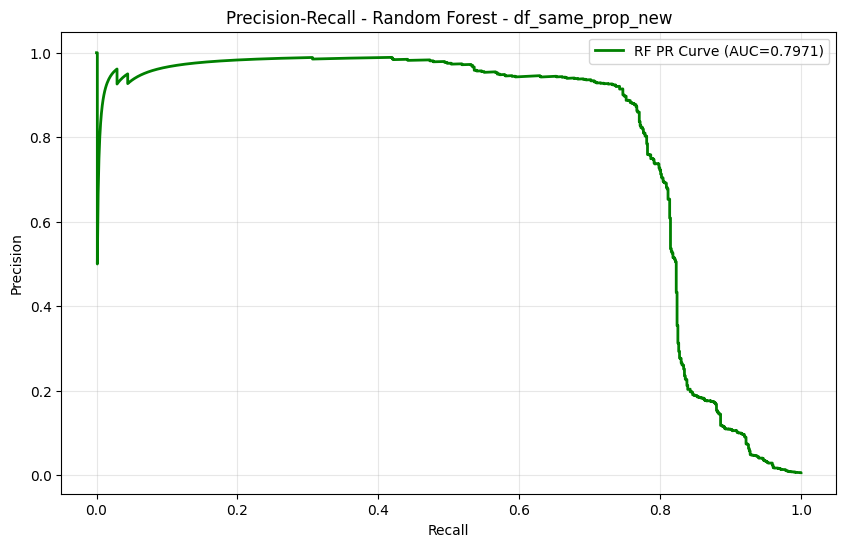

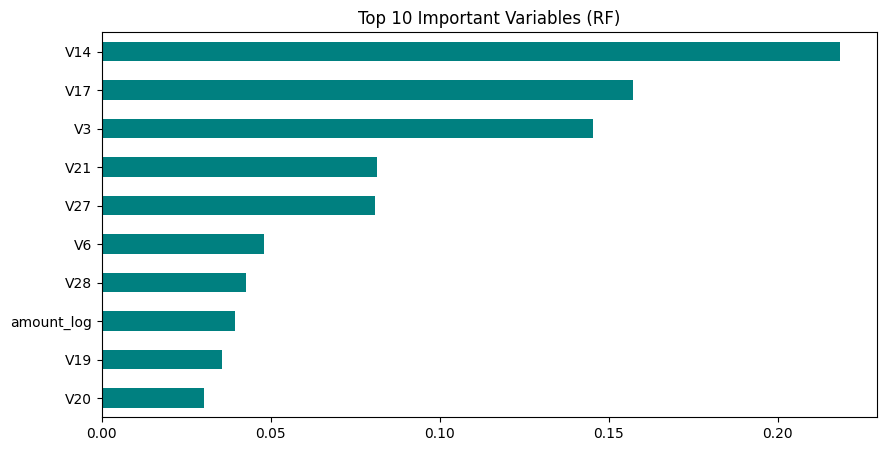

{'dataset': 'df_same_prop_new',
 'model': 'RandomForest_AllVars',
 'best_thresh_f2': np.float64(0.38321962030250534),
 'auc_pr': np.float64(0.7971187131579259),
 'roc_auc': np.float64(0.9677957704816987),
 'f1_fraude_05': np.float64(0.7959731543624161),
 'f2_fraude_05': np.float64(0.7295767716535434),
 'f1_fraude_opt': np.float64(0.8125384142593731),
 'f2_fraude_opt': np.float64(0.7867174482266127),
 'precision_at_f2_opt': np.float64(0.8595578673602081),
 'recall_at_f2_opt': np.float64(0.7703962703962703),
 'fraudes_totales': 858}

In [19]:
eval_desbalanceado_rf_all_vars(df_same_prop_new, "df_same_prop_new")

### Logistic Regression

In [1]:
def eval_desbalanceado_lr_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using LOGISTIC REGRESSION with metrics for extreme imbalance
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (Logistic Regression): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables before encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Encoding
    # ---------------------------------------------------------------------
    X_processed = pd.get_dummies(X_raw, drop_first=True)
    print(f"Variables after Encoding: {X_processed.shape[1]}")
    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 distinct days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning
    # ---------------------------------------------------------------------
    print("\n=== Correlation Analysis ===")

    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.90

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    print(f"Variables removed due to high correlation: {len(to_drop_corr)}")

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    # ---------------------------------------------------------------------
    # 5) Scaling
    # ---------------------------------------------------------------------
    print("\nApplying StandardScaler (necessary for LR)...")
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    print(f"Final variables for the model: {X_train_scaled.shape[1]}")

    # ---------------------------------------------------------------------
    # 6) Train Logistic Regression
    # ---------------------------------------------------------------------
    model = LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)
    # --- SAVE THE MODEL ---
    filename = f"lr_model_{name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved successfully as: {filename}")

    # Predictions
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Metrics and Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Search for best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f1_val = 2 * (prec_th * rec_th) / (prec_th + rec_th) if (prec_th + rec_th) > 0 else 0.0
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f1_val, f2_val))

    best_thresh_f2 = 0.5
    best_prec_f2 = 0.0
    best_rec_f2 = 0.0
    best_f1_score = 0.0
    best_f2_score = 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[4])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row

    # Optimal Matrix
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f1_05 = 2 * (prec_05 * rec_05) / ((prec_05) + rec_05) if ((prec_05) + rec_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | Precision: {prec_05:.4f} | F1: {f1_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold LR (Max F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F1 Score:  {best_f1_score:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")

    # ---------------------------------------------------------------------
    # 8) Plots and Coefficients
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'LR PR Curve (AUC={auc_pr:.4f})', color='navy', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Logistic Regression - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Coefficient Interpretation (Top 10 absolute)
    coeffs = pd.Series(model.coef_[0], index=X_train.columns)

    # Order by absolute magnitude
    top_coeffs = coeffs.abs().sort_values(ascending=False).head(10)
    top_coeffs_original = coeffs.loc[top_coeffs.index]

    colors = ['red' if x < 0 else 'blue' for x in top_coeffs_original]

    plt.figure(figsize=(10, 5))
    top_coeffs_original.plot(kind='barh', color=colors)
    plt.title("Top 10 Coefficients with highest impact")
    plt.xlabel("Coefficient Value (scaled data)")
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'dataset': name,
        'model': 'LogisticRegression_AllVars',
        'best_thresh_f2': best_thresh_f2,
        'auc_pr': auc_pr,
        'roc_auc': roc_auc,
        'f1_fraude_05': f1_05,
        'f2_fraude_05': f2_05,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }

NameError: name 'pd' is not defined

In [ ]:
eval_desbalanceado_lr_all_vars(df_same_prop_new, "df_same_prop_new")

### Hyperparameter tuning

Best model is random forest and the best dataset has been the one maintaining the proportion.



In [ ]:
def tune_and_eval_rf(df_in: pd.DataFrame, name: str, n_iter=3) -> dict:
    print(f"\n{'='*80}")
    print(f"Hyperparameter Tuning (RF)")
    print(f"{'='*80}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection and Encoding
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    # One-Hot Encoding
    X_processed = pd.get_dummies(X_raw, drop_first=True)

    # Re-inject date for the split
    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 2) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: At least 2 different days are required for Train/Test.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 3) Correlation Cleaning (Train Only)
    # ---------------------------------------------------------------------
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)

    print(f"Final vars: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 4) TUNING Definition (RandomizedSearchCV)
    # ---------------------------------------------------------------------
    f2_scorer = make_scorer(fbeta_score, beta=2)

    # Reduced grid for quick testing
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 10],
        'min_samples_leaf': [1, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', 'balanced_subsample']
    }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    # cv=3 * n_iter=3 = 9 total fits
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=f2_scorer,
        cv=StratifiedKFold(3),
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    print(f"\nStarting FAST search ({n_iter} iters * 3 folds = {n_iter*3} fits)...")

    random_search.fit(X_train, y_train)

    # --- SAVE THE MODEL ---
    filename = f"rf_hyperparameter_model_{name}.pkl"
    joblib.dump(random_search, filename)
    print(f"Model saved successfully as: {filename}")

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    print(f"\nBest parameters found: \n{best_params}")
    print(f"Best F2 Score in CV (Train): {random_search.best_score_:.4f}")

    # ---------------------------------------------------------------------
    # 5) Evaluation
    # ---------------------------------------------------------------------
    y_proba = best_model.predict_proba(X_test)[:, 1]

    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, f2_val))

    best_row = max(scores_list, key=lambda x: x[1]) if scores_list else (0.5, 0.0)
    best_thresh_f2, best_f2_score = best_row

    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm_opt.ravel()

    recall_opt = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_opt = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"\n--- TEST Results (Best Model) ---")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"AUC-PR:  {auc_pr:.4f}")
    print(f"Optimal Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score (Test):  {best_f2_score:.4f}")
    print(f"Recall (Test):    {recall_opt:.4f}")
    print(f"Precision (Test): {prec_opt:.4f}")

    # ---------------------------------------------------------------------
    # 6) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Best RF (AUC={auc_pr:.4f})', color='purple', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve - Tuned Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='indigo')
    plt.title("Top 10 Important Variables (Tuned RF)")
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'model': best_model,
        'best_params': best_params,
        'roc_auc': roc_auc,
        'f2_score': best_f2_score,
        'best_thresh': best_thresh_f2
    }


Hyperparameter Tuning (RF)
Train date: 2023-01-01 | Test date: 2023-01-02
Final vars: 251

Starting FAST search (3 iters * 3 folds = 9 fits)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Model saved successfully as: rf_hyperparameter_model_df_same_prop_new.pkl

Best parameters found: 
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced_subsample'}
Best F2 Score in CV (Train): 0.9194

--- TEST Results (Best Model) ---
ROC-AUC: 0.9683
AUC-PR:  0.7800
Optimal Threshold: 0.5164
F2 Score (Test):  0.7499
Recall (Test):    0.7506
Precision (Test): 0.7471


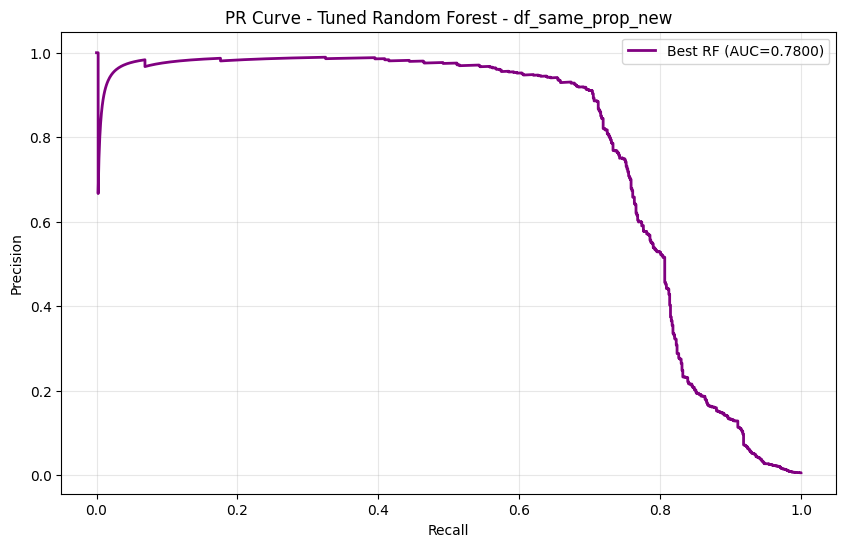

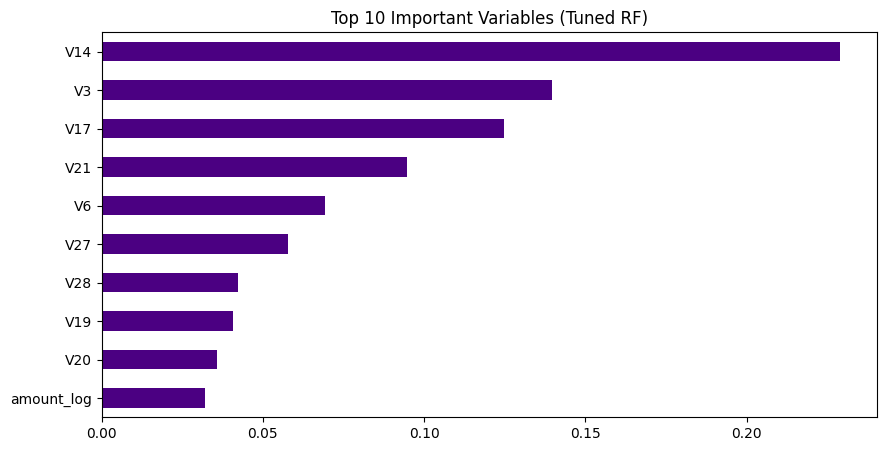

In [ ]:
results = tune_and_eval_rf(df_same_prop_new, "df_same_prop_new", n_iter=3)

We keep the predefined hyperparameters since this does not improve

## Dashboard Simulator Model

For the simulator page in the dashboard, we have decided to train a simpler model based on the user inputs since the anonymized PCA variables cannot be inputted. We calculate values for them to push towards fraud.

In [5]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/YEAR 4 - FALL/Data Science Project/csv_exports"

Mounted at /content/drive
/content/drive/MyDrive/YEAR 4 - FALL/Data Science Project/csv_exports


In [6]:
df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")

In [7]:
variables_pca = [f'V{i}' for i in range(1, 29)]
variables_especificas = [ 'customer_country', 'amount_log', 'timestamp']
VARIABLES_TO_KEEP = list(set(variables_especificas + variables_pca + ['Class']))
print(VARIABLES_TO_KEEP)
columnas_existentes = [c for c in VARIABLES_TO_KEEP if c in df_exp_same_prop.columns]
df_same_prop_new = df_exp_same_prop[columnas_existentes].copy()

['V22', 'V17', 'V5', 'V21', 'V2', 'V8', 'V20', 'V25', 'V27', 'V4', 'V28', 'V24', 'V11', 'Class', 'V6', 'V9', 'V13', 'V15', 'V16', 'V12', 'V19', 'V23', 'V10', 'V26', 'amount_log', 'timestamp', 'V1', 'customer_country', 'V7', 'V18', 'V14', 'V3']


In [8]:
df_same_prop_new.to_csv("df_same_prop_new.csv", index=False)

### PCA variable calculation

In [9]:
# Load model and get feature info
def load_model_and_features():
    """Load RandomForest model and return model + feature info"""

    try:
        model = joblib.load("rf_model_df_same_prop_new.pkl")

        # Get expected features
        if hasattr(model, 'feature_names_in_'):
            expected_features = list(model.feature_names_in_)
        elif hasattr(model, 'feature_names_'):
            expected_features = list(model.feature_names_)
        else:
            print("Warning: Cannot determine model features")
            return model, None, None

        # Load dataset to get statistics for neutral values
        df_stats = pd.read_csv("df_same_prop_new.csv")

        print(f"Model loaded successfully. Expected {len(expected_features)} features")
        return model, expected_features, df_stats
    except Exception as e:
        import traceback
        print(f"Error loading model: {e}")
        traceback.print_exc()
        return None, None, None


In [10]:
# Load model once at module level
MODEL, EXPECTED_FEATURES, DF_STATS = load_model_and_features()


Model loaded successfully. Expected 251 features


In [11]:
_FRAUD_PCA_CACHE = None
import itertools

In [13]:

# Prepare values of PCA variables that can simulate fraud
def find_fraud_pca_template(model, expected_features, df_stats):
    global _FRAUD_PCA_CACHE

    # Return cached result if available
    if _FRAUD_PCA_CACHE is not None:
        return _FRAUD_PCA_CACHE

    v_features = [f for f in expected_features if f.startswith("V") and f[1:].isdigit()]

    # Rank PCA features by importance
    importances = pd.Series(model.feature_importances_, index=expected_features)
    top_v = (
        importances[v_features]
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )

    ranges = {}
    for v in top_v:
        if df_stats is not None and v in df_stats.columns:
            q05 = df_stats[v].quantile(0.05)
            q95 = df_stats[v].quantile(0.95)
            ranges[v] = np.linspace(q05, q95, 4)
        else:
            ranges[v] = np.linspace(-3, 3, 4)

    base = {f: 0.0 for f in expected_features}
    best_proba = -1
    best_pca = {}

    for values in itertools.product(*ranges.values()):
        candidate = base.copy()
        for v, val in zip(ranges.keys(), values):
            candidate[v] = float(val)

        X = pd.DataFrame([candidate])[list(expected_features)]
        proba = model.predict_proba(X)[0, 1]

        if proba > best_proba:
            best_proba = proba
            best_pca = {v: candidate[v] for v in ranges.keys()}

    # Cache result
    _FRAUD_PCA_CACHE = best_pca
    print(best_pca)
    return best_pca


In [14]:
best_pca = find_fraud_pca_template(MODEL, EXPECTED_FEATURES, DF_STATS)

{'V14': -1.400272740503877, 'V17': 1.26972022761454, 'V3': -2.1380155662026246, 'V21': 0.5331025507790222, 'V27': 0.38669295421558797}
